In [209]:
pip install pyvi

Note: you may need to restart the kernel to use updated packages.


In [210]:
pip install gensim

Note: you may need to restart the kernel to use updated packages.


In [211]:
pip install vncorenlp

Note: you may need to restart the kernel to use updated packages.


In [212]:
!git clone https://github.com/vncorenlp/VnCoreNLP.git

fatal: destination path 'VnCoreNLP' already exists and is not an empty directory.


In [213]:
!rm -rf teencode.txt
!wget https://gist.githubusercontent.com/nguyenvanhieuvn/7d9441c10b3c2739499fc5a4d9ea06fb/raw/df939245b3e841b62af115be4dcb3516dadc9fc5/teencode.txt

--2023-12-20 12:47:56--  https://gist.githubusercontent.com/nguyenvanhieuvn/7d9441c10b3c2739499fc5a4d9ea06fb/raw/df939245b3e841b62af115be4dcb3516dadc9fc5/teencode.txt
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5656 (5.5K) [text/plain]
Saving to: 'teencode.txt'

teencode.txt        100%[===================>]   5.52K  --.-KB/s    in 0s      

2023-12-20 12:47:56 (55.5 MB/s) - 'teencode.txt' saved [5656/5656]



In [214]:
import sys
sys.path.insert(1, '/kaggle/input/preprocess')

from preprocess import (
    remove_HTML,
    convert_unicode,
    # standardize_sentence_typing,
    normalize_acronyms,
    #word_segmentation, # When use PhoBERT
    remove_unnecessary_characters
)

In [215]:
import pandas as pd
import numpy as np
import re
from pyvi import ViTokenizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.layers import Dense, Dropout, Concatenate, Input
from keras.layers import LSTM, Embedding, Bidirectional, GRU
from keras.layers import SpatialDropout1D, Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D
from keras.preprocessing.text import Tokenizer
import seaborn as sns
from gensim import models
from keras.initializers import Constant
from keras.preprocessing.sequence import pad_sequences
from keras.losses import BinaryCrossentropy, CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# I. Read Data

In [216]:
df_train = pd.read_csv('/kaggle/input/sneaker-reviews-2-0/train_data_final.csv')
df_val = pd.read_csv('/kaggle/input/sneaker-reviews-2-0/val_data_final.csv')
df_test = pd.read_csv('/kaggle/input/sneaker-reviews-2-0/test_data_final.csv')

In [217]:
df_train = df_train.rename(columns={'Review': 'Comment'})
df_val = df_val.rename(columns={'Review': 'Comment'})
df_test = df_test.rename(columns={'Review': 'Comment'})

In [218]:
df = pd.read_csv('/kaggle/input/sneaker-reviews/Raw data.csv')

In [219]:
df_train['Others'] = [-1] * len(df_train)
df_test['Others'] = [-1] * len(df_test)
df_val['Others'] = [-1] * len(df_val)

In [220]:
def convert_others(dft, df):
    for i in range(len(dft)):
        idx = df[df['Comment'] == dft['Comment'][i]].index.values[0]
        if type(df['Others'][idx]) == str:
            if(df['Others'][idx] == 'x'):
                dft.loc[i, 'Others'] = 2
            else:
                dft.loc[i, 'Others'] = int(df['Others'][idx])
    return dft

In [221]:
df_train = convert_others(df_train, df)
df_test = convert_others(df_test, df)
df_val = convert_others(df_val, df)

# II. Preprocess

In [222]:
import regex as re
import string
import emoji

from vncorenlp import VnCoreNLP
from nltk import flatten

In [223]:
def text_preprocess(text):
    text = remove_HTML(text)
    text = convert_unicode(text)
    # text = standardize_sentence_typing(text)
    text = normalize_acronyms(text)
    #text = word_segmentation(text) # When use PhoBERT
    text = remove_unnecessary_characters(text)
    return text.lower()
    #return text

In [224]:
WORDS_NO_UNIKEY = {
    "ă": "aw", "ắ": "aws", "ằ": "awf", "ẳ": "awr", "ẵ": "awx", "ặ": "awj",
    "â": "aa", "ấ": "aas", "ậ": "aaj", "ẩ": "aar", "ầ": "aaf", "ẫ": "aax",
    "á": "as", "à": "af", "ả": "ar", "ã": "ax", "ạ": "aj",
    "ô": "oo", "ố": "oos", "ồ": "oof", "ổ": "oor", "ỗ": "oox", "ộ": "ooj",
    "ó": "os", "ò": "of", "ỏ": "or", "õ": "ox", "ọ": "oj",
    "ơ": "ow", "ớ": "ows", "ờ": "owf", "ở": "owr", "ỡ": "owx", "ợ": "owj",
    "é": "es", "è": "ef", "ẻ": "er", "ẽ": "ex", "ẹ": "ej",
    "ê": "ee", "ế": "ees", "ề": "eef", "ể": "eer", "ễ": "eex", "ệ": "eej",
    "ú": "us", "ù": "uf", "ủ": "ur", "ũ": "ux", "ụ": "uj",
    "ư": "uw", "ứ": "uws", "ừ": "uwf", "ử": "uwr", "ữ": "uwx", "ự": "uwj",
    "í": "is", "ì": "if", "ỉ": "ir", "ị": "ij", "ĩ": "ix",
    "ý": "ys", "ỳ": "yf", "ỷ": "yr", "ỵ": "yj", "ỹ": "yx", "đ": "dd",
}

In [225]:
def remove_duplication(word):
    if word == '':
        return word
    prev_word = ""
    output = ""
    for c in word:
        if c != prev_word:
            _c = c.lower()
            raw_word = WORDS_NO_UNIKEY.get(_c, _c)[0]
            if prev_word == "" or raw_word != WORDS_NO_UNIKEY.get(prev_word, prev_word)[0]:
                output += c
                prev_word = raw_word
    return output

In [226]:
def preprocess(cm):
    new_cm = text_preprocess(cm)
    new_cm = remove_duplication(new_cm)
    new_cm = ViTokenizer.tokenize(new_cm)
    return new_cm

In [227]:
df_train['Preprocessed'] = df_train['Comment'].apply(preprocess)
df_val['Preprocessed'] = df_val['Comment'].apply(preprocess)
df_test['Preprocessed'] = df_test['Comment'].apply(preprocess)

In [228]:
cols = df_train.columns.drop(['Comment', 'Preprocessed'])
for col in cols:
    df_train[col] = df_train[col].astype(int)
    df_val[col] = df_val[col].astype(int)
    df_test[col] = df_test[col].astype(int)

In [229]:
df_train

,Comment,Price,Shipping,Outlook,Quality,Size,Shop_Service,General,Others,Preprocessed
0,"Giày đẹp, đi êm lắm",-1,-1,1,1,-1,-1,-1,-1,giày đẹp đi êm lắm
1,Mình săn sale với giá khá rẻ Chất lượng ok Sh...,1,1,-1,1,-1,-1,-1,-1,mình săn sale với giá khá rẻ chất_lượng ok shi...
2,Hình ảnh và video chỉ mang tính chất minh họa ...,1,1,-1,-1,-1,-1,1,-1,hình_ảnh và video chỉ mang tính_chất minh_họa ...
3,Mình đặt size 39 nhưng chật k đeo nổi. Còn giầ...,-1,1,1,-1,0,-1,-1,-1,mình đặt cỡ 39 nhưng chật không đeo nổi còn gi...
4,Nên mua nha mọi người đẹp xuất sắc lun ạ,-1,-1,1,-1,-1,-1,-1,-1,nên mua nha mọi người đẹp xuất_sắc lun ạ
...,...,...,...,...,...,...,...,...,...,...
8419,"sản phẩm như mô tả, chất lượng tốt, đáng sử dụ...",-1,-1,-1,1,-1,1,-1,-1,sản_phẩm như mô_tả chất_lượng tốt đáng sử_dụng...
8420,"sản phẩm tốt mọi nguòi nên mua ạ,giá tiền phù ...",2,-1,-1,-1,-1,-1,1,-1,sản_phẩm tốt mọi nguòi nên mua ạ giá tiền phù_...
8421,Nên mua nhé giày đẹp lắm ❤,-1,-1,1,-1,-1,-1,-1,-1,nên mua nhé giày đẹp lắm red_heart
8422,Hàng đẹp lắm ạ. Mk mua 2 đôi đều ưng ạ. Shop u...,-1,-1,1,-1,-1,1,-1,-1,hàng đẹp lắm ạ mình mua 2 đôi đều ưng ạ cửa_hà...


# III. Create Input

In [230]:
def get_label_stage_1(df):
    is_price = df.Price.replace({-1: 0, 0: 1, 2: 1})
    is_shipping = df.Shipping.replace({-1: 0, 0: 1, 2: 1})
    is_outlook = df.Outlook.replace({-1: 0, 0: 1, 2: 1})
    is_quality = df.Quality.replace({-1: 0, 0: 1, 2: 1})
    is_size = df.Size.replace({-1: 0, 0: 1, 2: 1})
    is_shopservice = df.Shop_Service.replace({-1: 0, 0: 1, 2: 1})
    is_general = df.General.replace({-1: 0, 0: 1, 2: 1})
    is_others = df.Others.replace({-1: 0, 0: 1, 2: 1})
    dict = {
          'is_price': is_price, 
          'is_shipping': is_shipping,
          'is_outlook': is_outlook,
          'is_quality': is_quality,
          'is_size': is_size,
          'is_shopservice': is_shopservice,
          'is_general': is_general, 
          'is_others': is_others
    }
    df_aspect = pd.DataFrame(dict)
    return df_aspect

In [231]:
def get_index_label(label_stage_df, aspect):
    return [indx_ for indx_ in label_stage_df[label_stage_df['is_{}'.format(aspect)]==1].index.values if indx_ != 0]

def get_list_index_label(label_stage_df, lst_aspect):
    lst_indx_label = {}
    for aspect in lst_aspect:
        lst_indx_label[aspect] = get_index_label(label_stage_df, aspect)
        
    return lst_indx_label

def get_data_stage_2(lst_indx_label, df):
    data = {}
    for aspect, indx in lst_indx_label.items():
        data[aspect] = df.iloc[indx]
    return data

def get_label_stage_2(df_input):
    df_stage_2 = df_input.copy()

    y_price = tf.keras.utils.to_categorical(df_stage_2['price'].Price, num_classes = 3)
    y_shipping = tf.keras.utils.to_categorical(df_stage_2['shipping'].Shipping, num_classes = 3)
    y_outlook = tf.keras.utils.to_categorical(df_stage_2['outlook'].Outlook, num_classes = 3)
    y_quality = tf.keras.utils.to_categorical(df_stage_2['quality'].Quality, num_classes = 3)
    y_others = df_stage_2['others'].Others.replace({-1:0}).to_numpy()
    y_size = tf.keras.utils.to_categorical(df_stage_2['size'].Size, num_classes = 3)
    y_shopservice = tf.keras.utils.to_categorical(df_stage_2['shopservice'].Shop_Service, num_classes = 3)
    y_general = tf.keras.utils.to_categorical(df_stage_2['general'].General, num_classes = 3)
    
    dict2 = {'price': y_price, 
             'shipping': y_shipping,
             'outlook': y_outlook,
             'quality': y_quality,
             'others': y_others,
             'size': y_size,
             'shopservice': y_shopservice,
             'general': y_general}
    del df_stage_2
    
    return dict2

In [232]:
def get_label_stage_3(df_input):
    df_stage_3 = df_input.copy()

    y_price = tf.keras.utils.to_categorical(df_stage_3['Price'], num_classes = 4)
    y_shipping = tf.keras.utils.to_categorical(df_stage_3['Shipping'], num_classes = 4)
    y_outlook = tf.keras.utils.to_categorical(df_stage_3['Outlook'], num_classes = 4)
    y_quality = tf.keras.utils.to_categorical(df_stage_3['Quality'], num_classes = 4)
    y_others = df_stage_3['Others'].replace({-1:0}).to_numpy()
    y_size = tf.keras.utils.to_categorical(df_stage_3['Size'], num_classes = 4)
    y_shopservice = tf.keras.utils.to_categorical(df_stage_3['Shop_Service'], num_classes = 4)
    y_general = tf.keras.utils.to_categorical(df_stage_3['General'], num_classes = 4)
    
    dict3 = {'price': y_price, 
             'shipping': y_shipping,
             'outlook': y_outlook,
             'quality': y_quality,
             'others': y_others,
             'size': y_size,
             'shopservice': y_shopservice,
             'general': y_general}
    del df_stage_3
    
    return dict3

In [233]:
def get_cmt(dict_df, lst_aspect):
    dict_cmt = {}
    for aspect in lst_aspect:
        dict_cmt[aspect] = dict_df[aspect]['Preprocessed'].values
    return dict_cmt

In [234]:
def get_array_label(df):
    label_stage_1_df = get_label_stage_1(df)
    lst_aspect = ['price', 'shipping', 'outlook', 'quality', 'size', 'shopservice', 'general', 'others']
    lst_indx = get_list_index_label(label_stage_1_df, lst_aspect)
    
    df_temp = get_data_stage_2(lst_indx, df)
    cmt_df = get_cmt(df_temp, lst_aspect)
    
    label_stage_2 = get_label_stage_2(df_temp)
    label_stage_3 = get_label_stage_3(df)
    del label_stage_1_df, lst_aspect, df_temp
    
    return cmt_df, label_stage_2, label_stage_3

In [235]:
df_train.shape, df_val.shape, df_test.shape

((8424, 10), (936, 10), (2340, 10))

In [236]:
label_aspect_train = get_label_stage_1(df_train)
label_aspect_val = get_label_stage_1(df_val)
label_aspect_test = get_label_stage_1(df_test)

In [237]:
label_aspect_train

,is_price,is_shipping,is_outlook,is_quality,is_size,is_shopservice,is_general,is_others
0,0,0,1,1,0,0,0,0
1,1,1,0,1,0,0,0,0
2,1,1,0,0,0,0,1,0
3,0,1,1,0,1,0,0,0
4,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
8419,0,0,0,1,0,1,0,0
8420,1,0,0,0,0,0,1,0
8421,0,0,1,0,0,0,0,0
8422,0,0,1,0,0,1,0,0


In [238]:
cmt_train, label_sentiment_train, lb_train = get_array_label(df_train)
cmt_val, label_sentiment_val, lb_val = get_array_label(df_val)
cmt_test, label_sentiment_test, lb_test = get_array_label(df_test)

# IV. Visualiztaion

In [239]:
num_words_train = [len(u.split(' ')) for u in df_train['Preprocessed']]
num_words_val = [len(u.split(' ')) for u in df_val['Preprocessed']]
num_words_test = [len(u.split(' ')) for u in df_test['Preprocessed']]

In [240]:
max(num_words_train), max(num_words_val), max(num_words_test)

(574, 309, 330)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

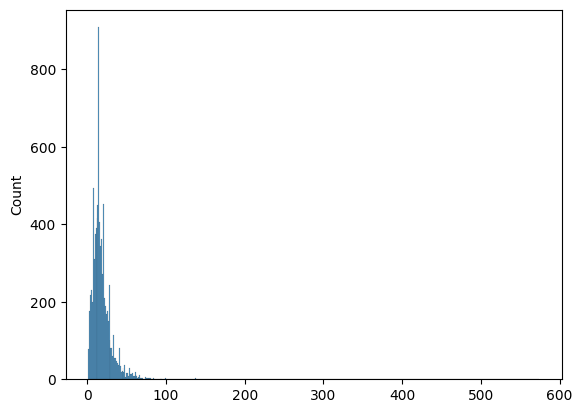

In [241]:
sns.histplot(num_words_train)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

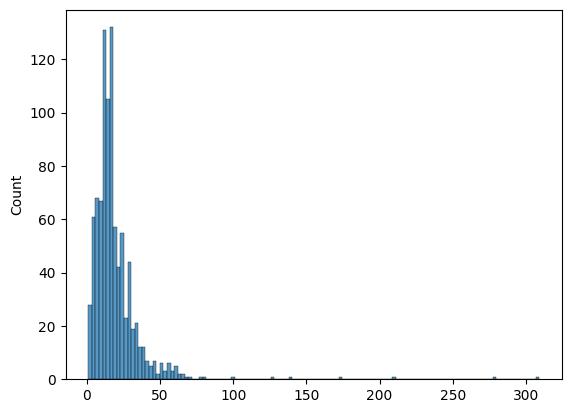

In [242]:
sns.histplot(num_words_val)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

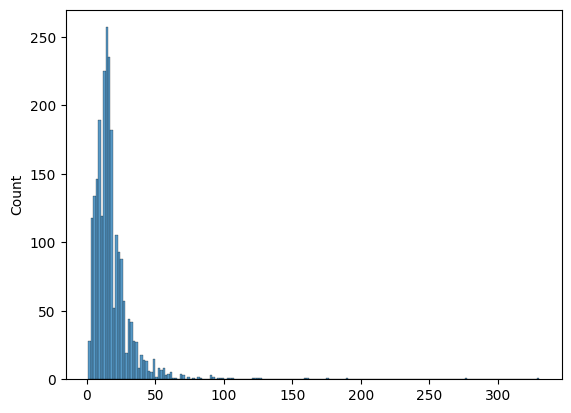

In [243]:
sns.histplot(num_words_test)

# V. Embedding

In [244]:
max_len = 200

In [245]:
def get_tokenize(train, val, test):
    tok = Tokenizer(filters='')
    tok.fit_on_texts(train)
    tok.fit_on_texts(val)
    tok.fit_on_texts(test)
    
    tokenized_train = tok.texts_to_sequences(train)
    tokenized_val = tok.texts_to_sequences(val)
    tokenized_test = tok.texts_to_sequences(test)
    
    return tok, tokenized_train, tokenized_val, tokenized_test 

In [246]:
def get_padded(max_len, tokenized_train, tokenized_val, tokenized_test):
    padded_train = pad_sequences(tokenized_train, padding = 'post', maxlen = max_len)
    padded_val = pad_sequences(tokenized_val, padding = 'post', maxlen = max_len)
    padded_test = pad_sequences(tokenized_test, padding = 'post', maxlen = max_len)
    
    return padded_train, padded_val, padded_test 

In [247]:
def get_embedding_matrix(embedding_dim, vocab_size, tok):
    embed_matrix = np.zeros(shape=(vocab_size, embedding_dim))
    word_failed = []

    for word, i in tok.word_index.items():
        try:
            embed_vector = w2c_model[word]
        except:
            word_failed.append(word)
        else:
            embed_matrix[i] = embed_vector
            
    return embed_matrix

In [248]:
w2v_path = '/kaggle/input/elmo-sen/elmo_aivivn_train_test_wikn_sen.txt'
w2c_model = models.KeyedVectors.load_word2vec_format(w2v_path, binary = False)

In [249]:
tokenizer_aspect, tokenized_aspect_train, tokenized_aspect_val, tokenized_aspect_test = get_tokenize(df_train['Preprocessed'].values, df_val['Preprocessed'].values, df_test['Preprocessed'].values)

In [250]:
padded_aspect_train, padded_aspect_val, padded_aspect_test = get_padded(max_len, tokenized_aspect_train, tokenized_aspect_val, tokenized_aspect_test)

In [251]:
embedding_dim = 1024 
vocab_aspect_size = len(tokenizer_aspect.word_index)+1
embedding_aspect_matrix = get_embedding_matrix(embedding_dim, vocab_aspect_size, tokenizer_aspect)

In [252]:
embedding_aspect_matrix.shape

(10034, 1024)

# VI. Model

## 1. BiLSTM-BiGru-Conv1D

## a) Build Model

In [253]:
def get_label(label_dict):
    return label_dict['price'], label_dict['shipping'],\
    label_dict['outlook'], label_dict['quality'], label_dict['size'],\
    label_dict['shopservice'], label_dict['general']#, label_dict['others']

In [254]:
price_train, shipping_train, outlook_train, quality_train,\
size_train, shopservice_train, general_train= get_label(lb_train)

price_val, shipping_val, outlook_val, quality_val,\
size_val, shopservice_val, general_val= get_label(lb_val)

price_test, shipping_test, outlook_test, quality_test,\
size_test, shopservice_test, general_test= get_label(lb_test)

In [255]:
num_label = 8

In [256]:
input = Input(shape=(max_len,))
embed = Embedding(input_dim=vocab_aspect_size,
                output_dim=embedding_dim,
                embeddings_initializer=Constant(embedding_aspect_matrix),
                input_length=max_len,
                trainable=True)(input)

dropout1 = SpatialDropout1D(0.2)(embed)

lstm = Bidirectional(LSTM(units = 200, activation = 'tanh', return_sequences = True))(dropout1)
conv_lstm = Conv1D(128, kernel_size = 2, padding = "valid", kernel_initializer = "he_uniform")(lstm)

gru = Bidirectional(GRU(units = 200, activation = 'tanh', return_sequences = True))(dropout1)
conv_gru = Conv1D(128, kernel_size = 2, padding = "valid", kernel_initializer = "he_uniform")(gru)


avg_pool1 = GlobalAveragePooling1D()(conv_lstm)
max_pool1 = GlobalMaxPooling1D()(conv_lstm)

avg_pool2 = GlobalAveragePooling1D()(conv_gru)
max_pool2 = GlobalMaxPooling1D()(conv_gru)
    
    
concat = Concatenate(axis=-1)([avg_pool1, max_pool1, avg_pool2, max_pool2])
dense1 = Dense(units = 256, activation = 'relu')(concat)
dense2 = Dense(units = 128, activation = 'relu')(dense1)
dropout1 = Dropout(rate = 0.2)(dense2)
dense3 = Dense(units = 64, activation = 'relu')(dropout1)
dense4 = Dense(units = 32, activation = 'relu')(dense3)


out_aspect = Dense(units = num_label, activation = 'sigmoid', name='out_aspect')(dense4)


out_price = Dense(units = 4, activation = 'softmax', name = 'out_price')(tf.concat([tf.gather(out_aspect, [0], axis=1), dense4], axis = 1))
out_shipping = Dense(units = 4, activation = 'softmax', name = 'out_shipping')(tf.concat([tf.gather(out_aspect, [1], axis=1), dense4], axis = 1))
out_outlook = Dense(units = 4, activation = 'softmax', name = 'out_outlook')(tf.concat([tf.gather(out_aspect, [2], axis=1), dense4], axis = 1))
out_quality = Dense(units = 4, activation = 'softmax', name = 'out_quality')(tf.concat([tf.gather(out_aspect, [3], axis=1), dense4], axis = 1))
out_size = Dense(units = 4, activation = 'softmax', name = 'out_size')(tf.concat([tf.gather(out_aspect, [4], axis=1), dense4], axis = 1))
out_shopservice = Dense(units = 4, activation = 'softmax', name = 'out_shopservice')(tf.concat([tf.gather(out_aspect, [5], axis=1), dense4], axis = 1))
out_general = Dense(units = 4, activation = 'softmax', name = 'out_general')(tf.concat([tf.gather(out_aspect, [6], axis=1), dense4], axis = 1))


model = tf.keras.Model(inputs = input, outputs = [out_aspect,
                                                  out_price, out_shipping, out_outlook, out_quality,
                                                  out_size, out_shopservice, out_general])

In [257]:
losses = {
    "out_aspect": "binary_crossentropy",
    "out_price": "categorical_crossentropy",
    "out_shipping": "categorical_crossentropy",
    "out_outlook": "categorical_crossentropy",
    "out_quality": "categorical_crossentropy",
    "out_size": "categorical_crossentropy",
    "out_shopservice": "categorical_crossentropy",
    "out_general": "categorical_crossentropy",
}

In [258]:
model.compile(optimizer=Adam(learning_rate = 0.0001), loss=losses, metrics=['acc'])

In [259]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 200)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 200, 1024)            1027481   ['input_1[0][0]']             
                                                          6                                       
                                                                                                  
 spatial_dropout1d (Spatial  (None, 200, 1024)            0         ['embedding[0][0]']           
 Dropout1D)                                                                                       
                                                                                              

In [260]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

## b) Train Model

In [261]:
history = model.fit(x=padded_aspect_train,
                    y={"out_aspect": label_aspect_train, "out_price": price_train, "out_shipping": shipping_train, 
                       "out_outlook": outlook_train, "out_quality": quality_train, "out_size": size_train, 
                       "out_shopservice": shopservice_train, "out_general": general_train},
                    validation_data=(padded_aspect_val, {"out_aspect": label_aspect_val, "out_price": price_val, "out_shipping": shipping_val, 
                                                  "out_outlook": outlook_val, "out_quality": quality_val, "out_size": size_val, 
                                                  "out_shopservice": shopservice_val, "out_general": general_val}),
                    batch_size = 128,
                    epochs=70,
                    callbacks = [callback],
                    verbose=1)

Epoch 1/70
66/66 [==============================] - 39s 351ms/step - loss: 7.4966 - out_aspect_loss: 0.7839 - out_price_loss: 0.8504 - out_shipping_loss: 0.9694 - out_outlook_loss: 1.0805 - out_quality_loss: 0.9752 - out_size_loss: 0.9108 - out_shopservice_loss: 1.0822 - out_general_loss: 0.8441 - out_aspect_acc: 0.0531 - out_price_acc: 0.7628 - out_shipping_acc: 0.6579 - out_outlook_acc: 0.5144 - out_quality_acc: 0.6861 - out_size_acc: 0.7219 - out_shopservice_acc: 0.6151 - out_general_acc: 0.7384 - val_loss: 6.1588 - val_out_aspect_loss: 0.7897 - val_out_price_loss: 0.6815 - val_out_shipping_loss: 0.6473 - val_out_outlook_loss: 0.8873 - val_out_quality_loss: 0.8186 - val_out_size_loss: 0.6943 - val_out_shopservice_loss: 0.9514 - val_out_general_loss: 0.6887 - val_out_aspect_acc: 0.0321 - val_out_price_acc: 0.8526 - val_out_shipping_acc: 0.8472 - val_out_outlook_acc: 0.7094 - val_out_quality_acc: 0.7126 - val_out_size_acc: 0.8355 - val_out_shopservice_acc: 0.7404 - val_out_general_acc

## c) Evaluation

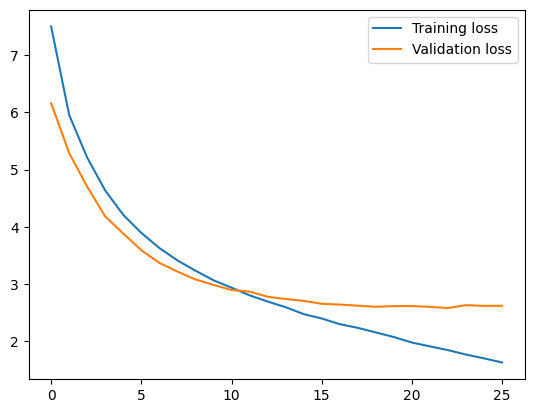

In [262]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

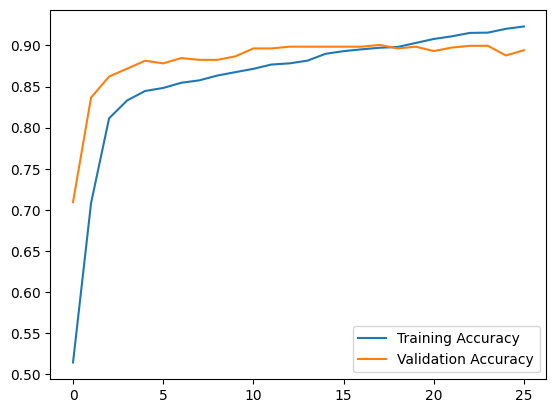

In [263]:
plt.plot(history.history['out_outlook_acc'], label='Training Accuracy')
plt.plot(history.history['val_out_outlook_acc'], label='Validation Accuracy')
plt.legend()

In [451]:
pred_test = model.predict(padded_aspect_test)
pred_val = model.predict(padded_aspect_val)

30/30 [==============================] - 1s 27ms/step


In [452]:
path = '/kaggle/working/'

In [453]:
def save_result_pred_aspect(pred_aspect, true_aspect, data_eval, model_type):
    df_pred = round(pd.DataFrame(pred_aspect), 0)
    df_true = pd.DataFrame(true_aspect)
    for i, aspect in enumerate(['price', 'shipping', 'outlook', 'quality',
                              'size', 'shopservice', 'general', 'others']):
        if data_eval == 'test':
            with open(f'{path}elmo_{model_type}_aspect_test_result.txt', "a") as dest:
                dest.write("Classification report for aspect: {} \n".format(aspect.upper()))
                dest.write(classification_report(df_true[f'is_{aspect}'], df_pred[i]))
    
        elif data_eval == 'eval':
            with open(f'{path}elmo_{model_type}_aspect_val_result.txt', "a") as dest:
                dest.write("Classification report for aspect: {} \n".format(aspect.upper()))
                dest.write(classification_report(df_true[f'is_{aspect}'], df_pred[i]))
        else:
            raise('data eval is invalid')

In [454]:
save_result_pred_aspect(pred_test[0], label_aspect_test, data_eval = 'test', model_type = 'bilstm_bigru_con')
save_result_pred_aspect(pred_val[0], label_aspect_val, data_eval = 'eval', model_type = 'bilstm_bigru_con')

In [455]:
pred_price_test = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping_test = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook_test = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality_test = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size_test = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice_test = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general_test = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [456]:
pred_price_val = np.where(np.argmax(pred_val[1], axis = 1)==3, -1, np.argmax(pred_val[1], axis = 1))
pred_shipping_val = np.where(np.argmax(pred_val[2], axis = 1)==3, -1, np.argmax(pred_val[2], axis = 1))
pred_outlook_val = np.where(np.argmax(pred_val[3], axis = 1)==3, -1, np.argmax(pred_val[3], axis = 1))
pred_quality_val = np.where(np.argmax(pred_val[4], axis = 1)==3, -1, np.argmax(pred_val[4], axis = 1))
pred_size_val = np.where(np.argmax(pred_val[5], axis = 1)==3, -1, np.argmax(pred_val[5], axis = 1))
pred_shopservice_val = np.where(np.argmax(pred_val[6], axis = 1)==3, -1, np.argmax(pred_val[6], axis = 1))
pred_general_val = np.where(np.argmax(pred_val[7], axis = 1)==3, -1, np.argmax(pred_val[7], axis = 1))

In [457]:
predict_dict_test = {'Price':pred_price_test, 'Shipping':pred_shipping_test, 'Outlook': pred_outlook_test,
                'Quality': pred_quality_test, 'Size': pred_size_test, 'Shop_Service': pred_shopservice_test,
                'General': pred_general_test}
predict_dict_val = {'Price':pred_price_val, 'Shipping':pred_shipping_val, 'Outlook': pred_outlook_val,
                'Quality': pred_quality_val, 'Size': pred_size_val, 'Shop_Service': pred_shopservice_val,
                'General': pred_general_val}

In [458]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_test[i], predict_dict_test[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.96      0.99      0.97      1999
           0       0.00      0.00      0.00         3
           1       0.86      0.81      0.84       247
           2       0.53      0.29      0.37        91

    accuracy                           0.94      2340
   macro avg       0.59      0.52      0.54      2340
weighted avg       0.93      0.94      0.93      2340

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.98      0.98      0.98      1635
           0       0.83      0.86      0.85       124
           1       0.92      0.95      0.94       549
           2       0.27      0.09      0.14        32

    accuracy                           0.95      2340
   macro avg       0.75      0.72      0.72      2340
weighted avg       0.95      0.95      0.95      2340

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [459]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_val[i], predict_dict_val[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.96      0.99      0.97       798
           0       0.00      0.00      0.00         1
           1       0.88      0.77      0.82       106
           2       0.50      0.29      0.37        31

    accuracy                           0.94       936
   macro avg       0.58      0.51      0.54       936
weighted avg       0.93      0.94      0.93       936

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.97      0.98      0.97       627
           0       0.84      0.86      0.85        50
           1       0.93      0.93      0.93       241
           2       0.33      0.11      0.17        18

    accuracy                           0.95       936
   macro avg       0.77      0.72      0.73       936
weighted avg       0.94      0.95      0.94       936

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [460]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bilstm_bigru_con_test_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_test[i], predict_dict_test[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [461]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bilstm_bigru_con_val_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_val[i],  predict_dict_val[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [275]:
def cmt_transform(cmt):
    cmt = [preprocess(cmt)]
    tokenized_cmt = tokenizer_aspect.texts_to_sequences(cmt)
    padded_cmt = pad_sequences(tokenized_cmt, padding = 'post', maxlen = 200)
    return padded_cmt

def predict_result(cmt):
    res = model.predict(cmt)
    sen_dict = {
        0: 'Negative',
        1: 'Positive',
        2: 'Neutral'
    }
    df_pred = round(pd.DataFrame(res[0]), 0)
    if df_pred[7][0] == 1:
        print('Others')
    else:
        pred_price_res = np.where(np.argmax(res[1], axis = 1)==3, -1, np.argmax(res[1], axis = 1))
        pred_shipping_res = np.where(np.argmax(res[2], axis = 1)==3, -1, np.argmax(res[2], axis = 1))
        pred_outlook_res = np.where(np.argmax(res[3], axis = 1)==3, -1, np.argmax(res[3], axis = 1))
        pred_quality_res = np.where(np.argmax(res[4], axis = 1)==3, -1, np.argmax(res[4], axis = 1))
        pred_size_res = np.where(np.argmax(res[5], axis = 1)==3, -1, np.argmax(res[5], axis = 1))
        pred_shopservice_res = np.where(np.argmax(res[6], axis = 1)==3, -1, np.argmax(res[6], axis = 1))
        pred_general_res = np.where(np.argmax(res[7], axis = 1)==3, -1, np.argmax(res[7], axis = 1))
        lst_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
        res_lst = [pred_price_res, pred_shipping_res, pred_outlook_res, pred_quality_res, pred_size_res, pred_shopservice_res, pred_general_res]
        for i in range(len(lst_aspect)):
            if(res_lst[i] != -1):
                print(lst_aspect[i], ':', sen_dict[int(res_lst[i])])

In [276]:
text = 'Giày siêu rẻ, đẹp, giao hàng nhanh nhưng đóng gói sơ sài'
predict_result(cmt_transform(text))

1/1 [==============================] - 0s 86ms/step
Price : Positive
Shipping : Positive
Outlook : Positive
Shop_Service : Negative


## d) Save Model

In [277]:
import pickle

In [278]:
pickle.dump(model, open('/kaggle/working/bilstm_bigru_conv1d.pkl', 'wb'))

In [279]:
model_load = pickle.load(open('/kaggle/working/bilstm_bigru_conv1d.pkl', 'rb'))

In [280]:
model_load.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 200)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 200, 1024)            1027481   ['input_1[0][0]']             
                                                          6                                       
                                                                                                  
 spatial_dropout1d (Spatial  (None, 200, 1024)            0         ['embedding[0][0]']           
 Dropout1D)                                                                                       
                                                                                              

## 2. BiLSTM

## a) Build Model

In [281]:
num_label = 8

In [282]:
input = Input(shape=(max_len,))
embed = Embedding(input_dim=vocab_aspect_size,
                output_dim=embedding_dim,
                embeddings_initializer=Constant(embedding_aspect_matrix),
                input_length=max_len,
                trainable=True)(input)



lstm = Bidirectional(LSTM(units = 200, activation = 'tanh'))(embed) 
dense2 = Dense(units = 128, activation = 'relu')(lstm)
dropout1 = Dropout(rate = 0.2)(dense2)
dense3 = Dense(units = 64, activation = 'relu')(dropout1)
dense4 = Dense(units = 32, activation = 'relu')(dense3)


out_aspect = Dense(units = num_label, activation = 'sigmoid', name='out_aspect')(dense4)


out_price = Dense(units = 4, activation = 'softmax', name = 'out_price')(tf.concat([tf.gather(out_aspect, [0], axis=1), dense4], axis = 1))
out_shipping = Dense(units = 4, activation = 'softmax', name = 'out_shipping')(tf.concat([tf.gather(out_aspect, [1], axis=1), dense4], axis = 1))
out_outlook = Dense(units = 4, activation = 'softmax', name = 'out_outlook')(tf.concat([tf.gather(out_aspect, [2], axis=1), dense4], axis = 1))
out_quality = Dense(units = 4, activation = 'softmax', name = 'out_quality')(tf.concat([tf.gather(out_aspect, [3], axis=1), dense4], axis = 1))
out_size = Dense(units = 4, activation = 'softmax', name = 'out_size')(tf.concat([tf.gather(out_aspect, [4], axis=1), dense4], axis = 1))
out_shopservice = Dense(units = 4, activation = 'softmax', name = 'out_shopservice')(tf.concat([tf.gather(out_aspect, [5], axis=1), dense4], axis = 1))
out_general = Dense(units = 4, activation = 'softmax', name = 'out_general')(tf.concat([tf.gather(out_aspect, [6], axis=1), dense4], axis = 1))


model_bi = tf.keras.Model(inputs = input, outputs = [out_aspect,
                                                  out_price, out_shipping, out_outlook, out_quality,
                                                  out_size, out_shopservice, out_general])

In [283]:
losses = {
    "out_aspect": "binary_crossentropy",
    "out_price": "categorical_crossentropy",
    "out_shipping": "categorical_crossentropy",
    "out_outlook": "categorical_crossentropy",
    "out_quality": "categorical_crossentropy",
    "out_size": "categorical_crossentropy",
    "out_shopservice": "categorical_crossentropy",
    "out_general": "categorical_crossentropy",
}

In [284]:
model_bi.compile(optimizer=Adam(learning_rate = 0.0001), loss=losses, metrics=['acc'])

In [285]:
model_bi.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 200)]                0         []                            
                                                                                                  
 embedding_1 (Embedding)     (None, 200, 1024)            1027481   ['input_2[0][0]']             
                                                          6                                       
                                                                                                  
 bidirectional_2 (Bidirecti  (None, 400)                  1960000   ['embedding_1[0][0]']         
 onal)                                                                                            
                                                                                            

In [286]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

## b) Train Model

In [287]:
history = model_bi.fit(x=padded_aspect_train,
                    y={"out_aspect": label_aspect_train, "out_price": price_train, "out_shipping": shipping_train, 
                       "out_outlook": outlook_train, "out_quality": quality_train, "out_size": size_train, 
                       "out_shopservice": shopservice_train, "out_general": general_train},
                    validation_data=(padded_aspect_val, {"out_aspect": label_aspect_val, "out_price": price_val, "out_shipping": shipping_val, 
                                                  "out_outlook": outlook_val, "out_quality": quality_val, "out_size": size_val, 
                                                  "out_shopservice": shopservice_val, "out_general": general_val}),
                    batch_size = 128,
                    epochs=70,
                    callbacks = [callback],
                    verbose=1)

Epoch 1/70
66/66 [==============================] - 22s 210ms/step - loss: 9.4973 - out_aspect_loss: 0.6450 - out_price_loss: 1.1415 - out_shipping_loss: 1.1685 - out_outlook_loss: 1.3267 - out_quality_loss: 1.4065 - out_size_loss: 1.2731 - out_shopservice_loss: 1.2602 - out_general_loss: 1.2759 - out_aspect_acc: 0.1781 - out_price_acc: 0.5201 - out_shipping_acc: 0.6559 - out_outlook_acc: 0.3129 - out_quality_acc: 0.3128 - out_size_acc: 0.3288 - out_shopservice_acc: 0.2926 - out_general_acc: 0.2778 - val_loss: 7.7750 - val_out_aspect_loss: 0.6121 - val_out_price_loss: 0.7463 - val_out_shipping_loss: 1.0482 - val_out_outlook_loss: 1.1974 - val_out_quality_loss: 1.3832 - val_out_size_loss: 1.0895 - val_out_shopservice_loss: 0.9058 - val_out_general_loss: 0.7927 - val_out_aspect_acc: 0.0737 - val_out_price_acc: 0.8504 - val_out_shipping_acc: 0.6699 - val_out_outlook_acc: 0.2393 - val_out_quality_acc: 0.7019 - val_out_size_acc: 0.8387 - val_out_shopservice_acc: 0.5865 - val_out_general_acc

## c) Evaluation

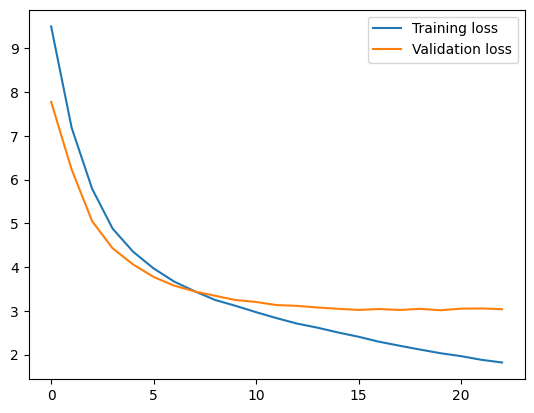

In [288]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

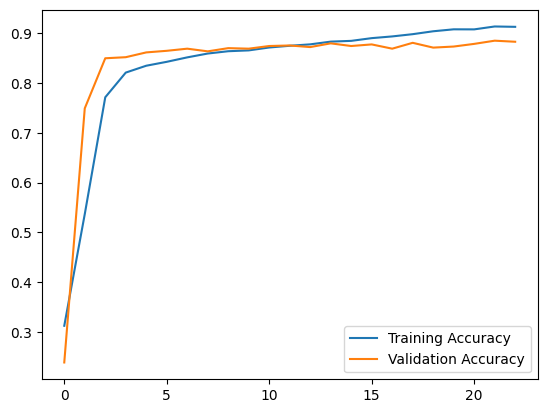

In [289]:
plt.plot(history.history['out_outlook_acc'], label='Training Accuracy')
plt.plot(history.history['val_out_outlook_acc'], label='Validation Accuracy')
plt.legend()

In [462]:
pred_test = model_bi.predict(padded_aspect_test)
pred_val = model_bi.predict(padded_aspect_val)

30/30 [==============================] - 0s 14ms/step


In [463]:
path = '/kaggle/working/'

In [464]:
save_result_pred_aspect(pred_test[0], label_aspect_test, data_eval = 'test', model_type = 'bilstm')
save_result_pred_aspect(pred_val[0], label_aspect_val, data_eval = 'eval', model_type = 'bilstm')

In [465]:
pred_price_test = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping_test = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook_test = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality_test = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size_test = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice_test = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general_test = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [466]:
pred_price_val = np.where(np.argmax(pred_val[1], axis = 1)==3, -1, np.argmax(pred_val[1], axis = 1))
pred_shipping_val = np.where(np.argmax(pred_val[2], axis = 1)==3, -1, np.argmax(pred_val[2], axis = 1))
pred_outlook_val = np.where(np.argmax(pred_val[3], axis = 1)==3, -1, np.argmax(pred_val[3], axis = 1))
pred_quality_val = np.where(np.argmax(pred_val[4], axis = 1)==3, -1, np.argmax(pred_val[4], axis = 1))
pred_size_val = np.where(np.argmax(pred_val[5], axis = 1)==3, -1, np.argmax(pred_val[5], axis = 1))
pred_shopservice_val = np.where(np.argmax(pred_val[6], axis = 1)==3, -1, np.argmax(pred_val[6], axis = 1))
pred_general_val = np.where(np.argmax(pred_val[7], axis = 1)==3, -1, np.argmax(pred_val[7], axis = 1))

In [467]:
predict_dict_test = {'Price':pred_price_test, 'Shipping':pred_shipping_test, 'Outlook': pred_outlook_test,
                'Quality': pred_quality_test, 'Size': pred_size_test, 'Shop_Service': pred_shopservice_test,
                'General': pred_general_test}
predict_dict_val = {'Price':pred_price_val, 'Shipping':pred_shipping_val, 'Outlook': pred_outlook_val,
                'Quality': pred_quality_val, 'Size': pred_size_val, 'Shop_Service': pred_shopservice_val,
                'General': pred_general_val}

In [468]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_test[i], predict_dict_test[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.95      0.98      0.96      1999
           0       0.00      0.00      0.00         3
           1       0.80      0.79      0.79       247
           2       0.49      0.22      0.30        91

    accuracy                           0.93      2340
   macro avg       0.56      0.50      0.51      2340
weighted avg       0.91      0.93      0.92      2340

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.97      0.97      0.97      1635
           0       0.78      0.73      0.76       124
           1       0.91      0.95      0.93       549
           2       0.10      0.03      0.05        32

    accuracy                           0.94      2340
   macro avg       0.69      0.67      0.67      2340
weighted avg       0.93      0.94      0.94      2340

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [469]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_val[i], predict_dict_val[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.95      0.98      0.96       798
           0       0.00      0.00      0.00         1
           1       0.86      0.75      0.80       106
           2       0.53      0.26      0.35        31

    accuracy                           0.93       936
   macro avg       0.59      0.50      0.53       936
weighted avg       0.92      0.93      0.92       936

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.94      0.98      0.96       627
           0       0.76      0.62      0.68        50
           1       0.90      0.90      0.90       241
           2       0.00      0.00      0.00        18

    accuracy                           0.92       936
   macro avg       0.65      0.62      0.64       936
weighted avg       0.91      0.92      0.91       936

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [470]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bilstm_test_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_test[i], predict_dict_test[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [471]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bilstm_val_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_val[i],  predict_dict_val[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

## d) Save Model

In [300]:
pickle.dump(model_bi, open('/kaggle/working/bilstm.pkl', 'wb'))

# 3. BiGRU

## a) Build Model

In [301]:
num_label = 8

In [302]:
input = Input(shape=(max_len,))
embed = Embedding(input_dim=vocab_aspect_size,
                output_dim=embedding_dim,
                embeddings_initializer=Constant(embedding_aspect_matrix),
                input_length=max_len,
                trainable=True)(input)



lstm = Bidirectional(GRU(units = 200, activation = 'tanh'))(embed) 
dense2 = Dense(units = 128, activation = 'relu')(lstm)
dropout1 = Dropout(rate = 0.2)(dense2)
dense3 = Dense(units = 64, activation = 'relu')(dropout1)
dense4 = Dense(units = 32, activation = 'relu')(dense3)


out_aspect = Dense(units = num_label, activation = 'sigmoid', name='out_aspect')(dense4)


out_price = Dense(units = 4, activation = 'softmax', name = 'out_price')(tf.concat([tf.gather(out_aspect, [0], axis=1), dense4], axis = 1))
out_shipping = Dense(units = 4, activation = 'softmax', name = 'out_shipping')(tf.concat([tf.gather(out_aspect, [1], axis=1), dense4], axis = 1))
out_outlook = Dense(units = 4, activation = 'softmax', name = 'out_outlook')(tf.concat([tf.gather(out_aspect, [2], axis=1), dense4], axis = 1))
out_quality = Dense(units = 4, activation = 'softmax', name = 'out_quality')(tf.concat([tf.gather(out_aspect, [3], axis=1), dense4], axis = 1))
out_size = Dense(units = 4, activation = 'softmax', name = 'out_size')(tf.concat([tf.gather(out_aspect, [4], axis=1), dense4], axis = 1))
out_shopservice = Dense(units = 4, activation = 'softmax', name = 'out_shopservice')(tf.concat([tf.gather(out_aspect, [5], axis=1), dense4], axis = 1))
out_general = Dense(units = 4, activation = 'softmax', name = 'out_general')(tf.concat([tf.gather(out_aspect, [6], axis=1), dense4], axis = 1))


model_big = tf.keras.Model(inputs = input, outputs = [out_aspect,
                                                  out_price, out_shipping, out_outlook, out_quality,
                                                  out_size, out_shopservice, out_general])

In [303]:
losses = {
    "out_aspect": "binary_crossentropy",
    "out_price": "categorical_crossentropy",
    "out_shipping": "categorical_crossentropy",
    "out_outlook": "categorical_crossentropy",
    "out_quality": "categorical_crossentropy",
    "out_size": "categorical_crossentropy",
    "out_shopservice": "categorical_crossentropy",
    "out_general": "categorical_crossentropy",
}

In [304]:
model_big.compile(optimizer=Adam(learning_rate = 0.0001), loss=losses, metrics=['acc'])

In [305]:
model_big.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 200)]                0         []                            
                                                                                                  
 embedding_2 (Embedding)     (None, 200, 1024)            1027481   ['input_3[0][0]']             
                                                          6                                       
                                                                                                  
 bidirectional_3 (Bidirecti  (None, 400)                  1471200   ['embedding_2[0][0]']         
 onal)                                                                                            
                                                                                            

In [306]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

## b) Train Model

In [307]:
history = model_big.fit(x=padded_aspect_train,
                    y={"out_aspect": label_aspect_train, "out_price": price_train, "out_shipping": shipping_train, 
                       "out_outlook": outlook_train, "out_quality": quality_train, "out_size": size_train, 
                       "out_shopservice": shopservice_train, "out_general": general_train},
                    validation_data=(padded_aspect_val, {"out_aspect": label_aspect_val, "out_price": price_val, "out_shipping": shipping_val, 
                                                  "out_outlook": outlook_val, "out_quality": quality_val, "out_size": size_val, 
                                                  "out_shopservice": shopservice_val, "out_general": general_val}),
                    batch_size = 128,
                    epochs=70,
                    callbacks = [callback],
                    verbose=1)

Epoch 1/70
66/66 [==============================] - 21s 203ms/step - loss: 7.7316 - out_aspect_loss: 0.7064 - out_price_loss: 0.7205 - out_shipping_loss: 1.1244 - out_outlook_loss: 1.1661 - out_quality_loss: 1.1589 - out_size_loss: 1.0328 - out_shopservice_loss: 0.9858 - out_general_loss: 0.8365 - out_aspect_acc: 0.1248 - out_price_acc: 0.8186 - out_shipping_acc: 0.4913 - out_outlook_acc: 0.4217 - out_quality_acc: 0.5034 - out_size_acc: 0.5816 - out_shopservice_acc: 0.7162 - out_general_acc: 0.7333 - val_loss: 6.2660 - val_out_aspect_loss: 0.7343 - val_out_price_loss: 0.5622 - val_out_shipping_loss: 0.8450 - val_out_outlook_loss: 0.9005 - val_out_quality_loss: 0.9868 - val_out_size_loss: 0.6980 - val_out_shopservice_loss: 0.8609 - val_out_general_loss: 0.6781 - val_out_aspect_acc: 0.1688 - val_out_price_acc: 0.8526 - val_out_shipping_acc: 0.7457 - val_out_outlook_acc: 0.6645 - val_out_quality_acc: 0.6998 - val_out_size_acc: 0.8397 - val_out_shopservice_acc: 0.7404 - val_out_general_acc

## c) Evaluation

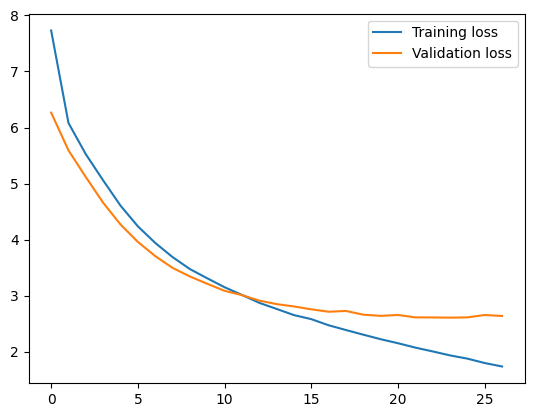

In [308]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

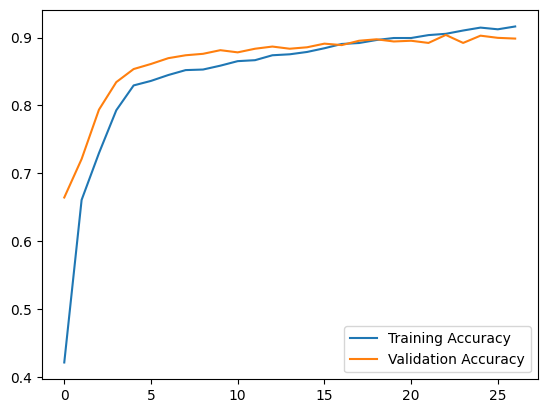

In [309]:
plt.plot(history.history['out_outlook_acc'], label='Training Accuracy')
plt.plot(history.history['val_out_outlook_acc'], label='Validation Accuracy')
plt.legend()

In [473]:
pred_test = model_big.predict(padded_aspect_test)
pred_val = model_big.predict(padded_aspect_val)

30/30 [==============================] - 0s 12ms/step


In [474]:
path = '/kaggle/working/'

In [475]:
def save_result_pred_aspect(pred_aspect, true_aspect, data_eval, model_type):
    df_pred = round(pd.DataFrame(pred_aspect), 0)
    df_true = pd.DataFrame(true_aspect)
    for i, aspect in enumerate(['price', 'shipping', 'outlook', 'quality',
                              'size', 'shopservice', 'general', 'others']):
        if data_eval == 'test':
            with open(f'{path}elmo_{model_type}_aspect_test_result.txt', "a") as dest:
                dest.write("Classification report for aspect: {} \n".format(aspect.upper()))
                dest.write(classification_report(df_true[f'is_{aspect}'], df_pred[i]))
    
        elif data_eval == 'eval':
            with open(f'{path}elmo_{model_type}_aspect_val_result.txt', "a") as dest:
                dest.write("Classification report for aspect: {} \n".format(aspect.upper()))
                dest.write(classification_report(df_true[f'is_{aspect}'], df_pred[i]))
        else:
            raise('data eval is invalid')

In [476]:
save_result_pred_aspect(pred_test[0], label_aspect_test, data_eval = 'test', model_type = 'bigru')
save_result_pred_aspect(pred_val[0], label_aspect_val, data_eval = 'eval', model_type = 'bigru')

In [477]:
pred_price_test = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping_test = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook_test = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality_test = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size_test = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice_test = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general_test = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [478]:
pred_price_val = np.where(np.argmax(pred_val[1], axis = 1)==3, -1, np.argmax(pred_val[1], axis = 1))
pred_shipping_val = np.where(np.argmax(pred_val[2], axis = 1)==3, -1, np.argmax(pred_val[2], axis = 1))
pred_outlook_val = np.where(np.argmax(pred_val[3], axis = 1)==3, -1, np.argmax(pred_val[3], axis = 1))
pred_quality_val = np.where(np.argmax(pred_val[4], axis = 1)==3, -1, np.argmax(pred_val[4], axis = 1))
pred_size_val = np.where(np.argmax(pred_val[5], axis = 1)==3, -1, np.argmax(pred_val[5], axis = 1))
pred_shopservice_val = np.where(np.argmax(pred_val[6], axis = 1)==3, -1, np.argmax(pred_val[6], axis = 1))
pred_general_val = np.where(np.argmax(pred_val[7], axis = 1)==3, -1, np.argmax(pred_val[7], axis = 1))

In [479]:
predict_dict_test = {'Price':pred_price_test, 'Shipping':pred_shipping_test, 'Outlook': pred_outlook_test,
                'Quality': pred_quality_test, 'Size': pred_size_test, 'Shop_Service': pred_shopservice_test,
                'General': pred_general_test}
predict_dict_val = {'Price':pred_price_val, 'Shipping':pred_shipping_val, 'Outlook': pred_outlook_val,
                'Quality': pred_quality_val, 'Size': pred_size_val, 'Shop_Service': pred_shopservice_val,
                'General': pred_general_val}

In [480]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_test[i], predict_dict_test[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.96      0.98      0.97      1999
           0       0.00      0.00      0.00         3
           1       0.84      0.81      0.83       247
           2       0.59      0.41      0.48        91

    accuracy                           0.94      2340
   macro avg       0.60      0.55      0.57      2340
weighted avg       0.93      0.94      0.93      2340

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.98      0.98      0.98      1635
           0       0.84      0.80      0.82       124
           1       0.90      0.95      0.92       549
           2       0.00      0.00      0.00        32

    accuracy                           0.95      2340
   macro avg       0.68      0.68      0.68      2340
weighted avg       0.94      0.95      0.94      2340

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [481]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_val[i], predict_dict_val[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.96      0.97      0.97       798
           0       0.00      0.00      0.00         1
           1       0.82      0.80      0.81       106
           2       0.42      0.35      0.39        31

    accuracy                           0.93       936
   macro avg       0.55      0.53      0.54       936
weighted avg       0.93      0.93      0.93       936

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.97      0.98      0.97       627
           0       0.86      0.74      0.80        50
           1       0.89      0.95      0.92       241
           2       0.00      0.00      0.00        18

    accuracy                           0.94       936
   macro avg       0.68      0.67      0.67       936
weighted avg       0.92      0.94      0.93       936

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [482]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bigru_test_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_test[i], predict_dict_test[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [483]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bigru_val_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_val[i], predict_dict_val[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

## d) Save Model

In [322]:
pickle.dump(model_big, open('/kaggle/working/bigru.pkl', 'wb'))

## 4. BiLSTM + Conv1D

In [323]:
num_label = 8

In [324]:
input = Input(shape=(max_len,))
embed = Embedding(input_dim=vocab_aspect_size,
                output_dim=embedding_dim,
                embeddings_initializer=Constant(embedding_aspect_matrix),
                input_length=max_len,
                trainable=True)(input)



dropout1 = SpatialDropout1D(0.2)(embed)

lstm = Bidirectional(LSTM(units = 200, activation = 'tanh', return_sequences = True))(dropout1)
conv = Conv1D(128, kernel_size = 2, padding = "valid", kernel_initializer = "he_uniform")(lstm)

avg_pool1 = GlobalAveragePooling1D()(conv)
max_pool1 = GlobalMaxPooling1D()(conv)
    
concat = Concatenate(axis=-1)([avg_pool1, max_pool1])
dense2 = Dense(units = 128, activation = 'relu')(concat)
dropout1 = Dropout(rate = 0.2)(dense2)
dense3 = Dense(units = 64, activation = 'relu')(dropout1)
dense4 = Dense(units = 32, activation = 'relu')(dense3)


out_aspect = Dense(units = num_label, activation = 'sigmoid', name='out_aspect')(dense4)


out_price = Dense(units = 4, activation = 'softmax', name = 'out_price')(tf.concat([tf.gather(out_aspect, [0], axis=1), dense4], axis = 1))
out_shipping = Dense(units = 4, activation = 'softmax', name = 'out_shipping')(tf.concat([tf.gather(out_aspect, [1], axis=1), dense4], axis = 1))
out_outlook = Dense(units = 4, activation = 'softmax', name = 'out_outlook')(tf.concat([tf.gather(out_aspect, [2], axis=1), dense4], axis = 1))
out_quality = Dense(units = 4, activation = 'softmax', name = 'out_quality')(tf.concat([tf.gather(out_aspect, [3], axis=1), dense4], axis = 1))
out_size = Dense(units = 4, activation = 'softmax', name = 'out_size')(tf.concat([tf.gather(out_aspect, [4], axis=1), dense4], axis = 1))
out_shopservice = Dense(units = 4, activation = 'softmax', name = 'out_shopservice')(tf.concat([tf.gather(out_aspect, [5], axis=1), dense4], axis = 1))
out_general = Dense(units = 4, activation = 'softmax', name = 'out_general')(tf.concat([tf.gather(out_aspect, [6], axis=1), dense4], axis = 1))


model_bil_con = tf.keras.Model(inputs = input, outputs = [out_aspect,
                                                  out_price, out_shipping, out_outlook, out_quality,
                                                  out_size, out_shopservice, out_general])

In [325]:
losses = {
    "out_aspect": "binary_crossentropy",
    "out_price": "categorical_crossentropy",
    "out_shipping": "categorical_crossentropy",
    "out_outlook": "categorical_crossentropy",
    "out_quality": "categorical_crossentropy",
    "out_size": "categorical_crossentropy",
    "out_shopservice": "categorical_crossentropy",
    "out_general": "categorical_crossentropy",
}

In [326]:
model_bil_con.compile(optimizer=Adam(learning_rate = 0.0001), loss=losses, metrics=['acc'])

In [327]:
model_bil_con.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 200)]                0         []                            
                                                                                                  
 embedding_3 (Embedding)     (None, 200, 1024)            1027481   ['input_4[0][0]']             
                                                          6                                       
                                                                                                  
 spatial_dropout1d_1 (Spati  (None, 200, 1024)            0         ['embedding_3[0][0]']         
 alDropout1D)                                                                                     
                                                                                            

In [328]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

## b) Train Model

In [329]:
history = model_bil_con.fit(x=padded_aspect_train,
                    y={"out_aspect": label_aspect_train, "out_price": price_train, "out_shipping": shipping_train, 
                       "out_outlook": outlook_train, "out_quality": quality_train, "out_size": size_train, 
                       "out_shopservice": shopservice_train, "out_general": general_train},
                    validation_data=(padded_aspect_val, {"out_aspect": label_aspect_val, "out_price": price_val, "out_shipping": shipping_val, 
                                                  "out_outlook": outlook_val, "out_quality": quality_val, "out_size": size_val, 
                                                  "out_shopservice": shopservice_val, "out_general": general_val}),
                    batch_size = 128,
                    epochs=70,
                    callbacks = [callback],
                    verbose=1)

Epoch 1/70
66/66 [==============================] - 24s 223ms/step - loss: 8.7948 - out_aspect_loss: 0.6322 - out_price_loss: 1.4060 - out_shipping_loss: 1.1183 - out_outlook_loss: 1.2232 - out_quality_loss: 1.1965 - out_size_loss: 1.0571 - out_shopservice_loss: 1.2453 - out_general_loss: 0.9161 - out_aspect_acc: 0.2944 - out_price_acc: 0.0876 - out_shipping_acc: 0.6797 - out_outlook_acc: 0.4569 - out_quality_acc: 0.6364 - out_size_acc: 0.7331 - out_shopservice_acc: 0.3197 - out_general_acc: 0.7276 - val_loss: 7.2945 - val_out_aspect_loss: 0.6301 - val_out_price_loss: 1.1606 - val_out_shipping_loss: 0.8819 - val_out_outlook_loss: 0.9196 - val_out_quality_loss: 1.1027 - val_out_size_loss: 0.8371 - val_out_shopservice_loss: 1.0650 - val_out_general_loss: 0.6974 - val_out_aspect_acc: 0.2831 - val_out_price_acc: 0.5150 - val_out_shipping_acc: 0.6667 - val_out_outlook_acc: 0.5577 - val_out_quality_acc: 0.6976 - val_out_size_acc: 0.8397 - val_out_shopservice_acc: 0.5865 - val_out_general_acc

## c) Evaluation

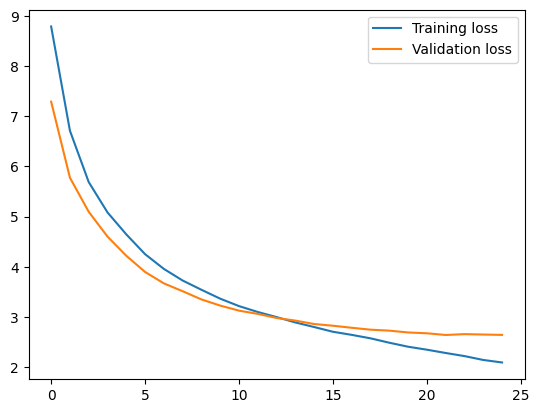

In [330]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

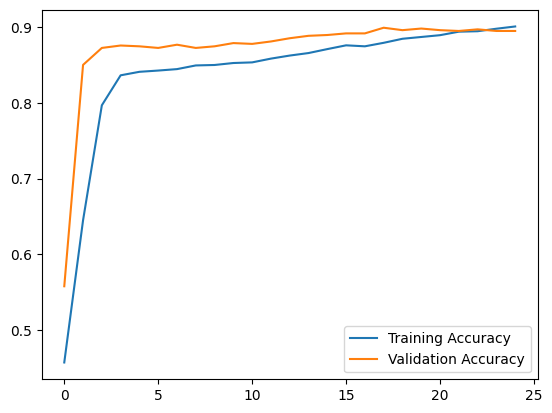

In [331]:
plt.plot(history.history['out_outlook_acc'], label='Training Accuracy')
plt.plot(history.history['val_out_outlook_acc'], label='Validation Accuracy')
plt.legend()

In [332]:
pred_test = model_bil_con.predict(padded_aspect_test)
pred_val = model_bil_con.predict(padded_aspect_val)

30/30 [==============================] - 0s 15ms/step


In [333]:
path = '/kaggle/working/'

In [334]:
save_result_pred_aspect(pred_test[0], label_aspect_test, data_eval = 'test', model_type = 'bilstm_con')
save_result_pred_aspect(pred_val[0], label_aspect_val, data_eval = 'eval', model_type = 'bilstm_con')

In [335]:
pred_price_test = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping_test = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook_test = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality_test = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size_test = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice_test = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general_test = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [336]:
pred_price_val = np.where(np.argmax(pred_val[1], axis = 1)==3, -1, np.argmax(pred_val[1], axis = 1))
pred_shipping_val = np.where(np.argmax(pred_val[2], axis = 1)==3, -1, np.argmax(pred_val[2], axis = 1))
pred_outlook_val = np.where(np.argmax(pred_val[3], axis = 1)==3, -1, np.argmax(pred_val[3], axis = 1))
pred_quality_val = np.where(np.argmax(pred_val[4], axis = 1)==3, -1, np.argmax(pred_val[4], axis = 1))
pred_size_val = np.where(np.argmax(pred_val[5], axis = 1)==3, -1, np.argmax(pred_val[5], axis = 1))
pred_shopservice_val = np.where(np.argmax(pred_val[6], axis = 1)==3, -1, np.argmax(pred_val[6], axis = 1))
pred_general_val = np.where(np.argmax(pred_val[7], axis = 1)==3, -1, np.argmax(pred_val[7], axis = 1))

In [337]:
predict_dict_test = {'Price':pred_price_test, 'Shipping':pred_shipping_test, 'Outlook': pred_outlook_test,
                'Quality': pred_quality_test, 'Size': pred_size_test, 'Shop_Service': pred_shopservice_test,
                'General': pred_general_test}
predict_dict_val = {'Price':pred_price_val, 'Shipping':pred_shipping_val, 'Outlook': pred_outlook_val,
                'Quality': pred_quality_val, 'Size': pred_size_val, 'Shop_Service': pred_shopservice_val,
                'General': pred_general_val}

In [338]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_test[i], predict_dict_test[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.95      0.99      0.97      1999
           0       0.00      0.00      0.00         3
           1       0.87      0.78      0.82       247
           2       0.55      0.19      0.28        91

    accuracy                           0.94      2340
   macro avg       0.59      0.49      0.52      2340
weighted avg       0.92      0.94      0.93      2340

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.97      0.98      0.97      1635
           0       0.80      0.84      0.82       124
           1       0.91      0.95      0.93       549
           2       0.00      0.00      0.00        32

    accuracy                           0.95      2340
   macro avg       0.67      0.69      0.68      2340
weighted avg       0.94      0.95      0.94      2340

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [339]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_val[i], predict_dict_val[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.94      0.99      0.97       798
           0       0.00      0.00      0.00         1
           1       0.92      0.76      0.84       106
           2       0.22      0.06      0.10        31

    accuracy                           0.93       936
   macro avg       0.52      0.45      0.48       936
weighted avg       0.91      0.93      0.92       936

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.96      0.99      0.97       627
           0       0.80      0.82      0.81        50
           1       0.94      0.93      0.93       241
           2       0.00      0.00      0.00        18

    accuracy                           0.94       936
   macro avg       0.67      0.68      0.68       936
weighted avg       0.93      0.94      0.93       936

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [340]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bil_con_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_test[i], predict_dict_test[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [341]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bil_con_val_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_val[i], predict_dict_val[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

## d) Save Model

In [342]:
pickle.dump(model_bil_con, open('/kaggle/working/bilstm_conv1d.pkl', 'wb'))

## 5. BiGRU + Conv1D

In [343]:
num_label = 8

In [344]:
input = Input(shape=(max_len,))
embed = Embedding(input_dim=vocab_aspect_size,
                output_dim=embedding_dim,
                embeddings_initializer=Constant(embedding_aspect_matrix),
                input_length=max_len,
                trainable=True)(input)



dropout1 = SpatialDropout1D(0.2)(embed)

lstm = Bidirectional(GRU(units = 200, activation = 'tanh', return_sequences = True))(dropout1)
conv = Conv1D(128, kernel_size = 2, padding = "valid", kernel_initializer = "he_uniform")(lstm)

avg_pool1 = GlobalAveragePooling1D()(conv)
max_pool1 = GlobalMaxPooling1D()(conv)
    
concat = Concatenate(axis=-1)([avg_pool1, max_pool1])
dense2 = Dense(units = 128, activation = 'relu')(concat)
dropout1 = Dropout(rate = 0.2)(dense2)
dense3 = Dense(units = 64, activation = 'relu')(dropout1)
dense4 = Dense(units = 32, activation = 'relu')(dense3)


out_aspect = Dense(units = num_label, activation = 'sigmoid', name='out_aspect')(dense4)


out_price = Dense(units = 4, activation = 'softmax', name = 'out_price')(tf.concat([tf.gather(out_aspect, [0], axis=1), dense4], axis = 1))
out_shipping = Dense(units = 4, activation = 'softmax', name = 'out_shipping')(tf.concat([tf.gather(out_aspect, [1], axis=1), dense4], axis = 1))
out_outlook = Dense(units = 4, activation = 'softmax', name = 'out_outlook')(tf.concat([tf.gather(out_aspect, [2], axis=1), dense4], axis = 1))
out_quality = Dense(units = 4, activation = 'softmax', name = 'out_quality')(tf.concat([tf.gather(out_aspect, [3], axis=1), dense4], axis = 1))
out_size = Dense(units = 4, activation = 'softmax', name = 'out_size')(tf.concat([tf.gather(out_aspect, [4], axis=1), dense4], axis = 1))
out_shopservice = Dense(units = 4, activation = 'softmax', name = 'out_shopservice')(tf.concat([tf.gather(out_aspect, [5], axis=1), dense4], axis = 1))
out_general = Dense(units = 4, activation = 'softmax', name = 'out_general')(tf.concat([tf.gather(out_aspect, [6], axis=1), dense4], axis = 1))


model_big_con = tf.keras.Model(inputs = input, outputs = [out_aspect,
                                                  out_price, out_shipping, out_outlook, out_quality,
                                                  out_size, out_shopservice, out_general])

In [345]:
losses = {
    "out_aspect": "binary_crossentropy",
    "out_price": "categorical_crossentropy",
    "out_shipping": "categorical_crossentropy",
    "out_outlook": "categorical_crossentropy",
    "out_quality": "categorical_crossentropy",
    "out_size": "categorical_crossentropy",
    "out_shopservice": "categorical_crossentropy",
    "out_general": "categorical_crossentropy",
}

In [346]:
model_big_con.compile(optimizer=Adam(learning_rate = 0.0001), loss=losses, metrics=['acc'])

In [347]:
model_big_con.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 200)]                0         []                            
                                                                                                  
 embedding_4 (Embedding)     (None, 200, 1024)            1027481   ['input_5[0][0]']             
                                                          6                                       
                                                                                                  
 spatial_dropout1d_2 (Spati  (None, 200, 1024)            0         ['embedding_4[0][0]']         
 alDropout1D)                                                                                     
                                                                                            

In [348]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

## b) Train Model

In [349]:
history = model_big_con.fit(x=padded_aspect_train,
                    y={"out_aspect": label_aspect_train, "out_price": price_train, "out_shipping": shipping_train, 
                       "out_outlook": outlook_train, "out_quality": quality_train, "out_size": size_train, 
                       "out_shopservice": shopservice_train, "out_general": general_train},
                    validation_data=(padded_aspect_val, {"out_aspect": label_aspect_val, "out_price": price_val, "out_shipping": shipping_val, 
                                                  "out_outlook": outlook_val, "out_quality": quality_val, "out_size": size_val, 
                                                  "out_shopservice": shopservice_val, "out_general": general_val}),
                    batch_size = 128,
                    epochs=70,
                    callbacks = [callback],
                    verbose=1)

Epoch 1/70
66/66 [==============================] - 22s 203ms/step - loss: 7.7807 - out_aspect_loss: 0.6341 - out_price_loss: 1.0367 - out_shipping_loss: 0.9068 - out_outlook_loss: 1.0457 - out_quality_loss: 1.0515 - out_size_loss: 0.8925 - out_shopservice_loss: 1.0347 - out_general_loss: 1.1788 - out_aspect_acc: 0.1452 - out_price_acc: 0.6924 - out_shipping_acc: 0.6976 - out_outlook_acc: 0.5167 - out_quality_acc: 0.5857 - out_size_acc: 0.8153 - out_shopservice_acc: 0.6661 - out_general_acc: 0.4211 - val_loss: 6.3042 - val_out_aspect_loss: 0.5898 - val_out_price_loss: 0.8671 - val_out_shipping_loss: 0.6869 - val_out_outlook_loss: 0.7860 - val_out_quality_loss: 0.8652 - val_out_size_loss: 0.8806 - val_out_shopservice_loss: 0.8871 - val_out_general_loss: 0.7415 - val_out_aspect_acc: 0.2361 - val_out_price_acc: 0.8526 - val_out_shipping_acc: 0.7158 - val_out_outlook_acc: 0.7297 - val_out_quality_acc: 0.7019 - val_out_size_acc: 0.8344 - val_out_shopservice_acc: 0.7404 - val_out_general_acc

## c) Evaluation

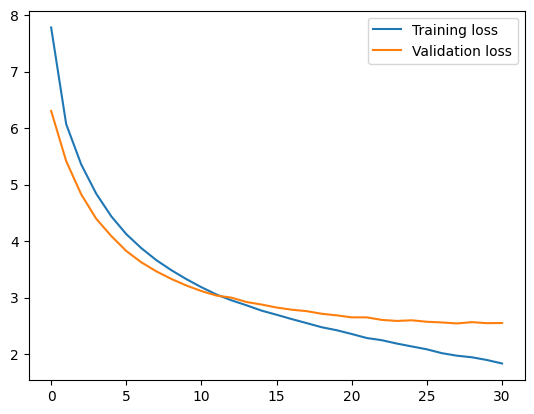

In [350]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()

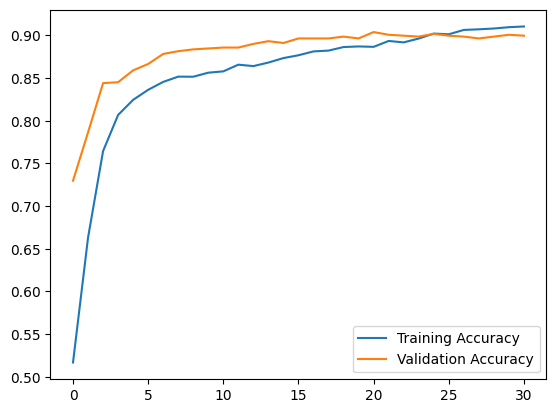

In [351]:
plt.plot(history.history['out_outlook_acc'], label='Training Accuracy')
plt.plot(history.history['val_out_outlook_acc'], label='Validation Accuracy')
plt.legend()

In [352]:
pred_test = model_big_con.predict(padded_aspect_test)
pred_val = model_big_con.predict(padded_aspect_val)

30/30 [==============================] - 0s 13ms/step


In [353]:
path = '/kaggle/working/'

In [354]:
save_result_pred_aspect(pred_test[0], label_aspect_test, data_eval = 'test', model_type = 'bigru_con')
save_result_pred_aspect(pred_val[0], label_aspect_val, data_eval = 'eval', model_type = 'bigru_con')

In [355]:
pred_price_test = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping_test = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook_test = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality_test = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size_test = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice_test = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general_test = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [356]:
pred_price_val = np.where(np.argmax(pred_val[1], axis = 1)==3, -1, np.argmax(pred_val[1], axis = 1))
pred_shipping_val = np.where(np.argmax(pred_val[2], axis = 1)==3, -1, np.argmax(pred_val[2], axis = 1))
pred_outlook_val = np.where(np.argmax(pred_val[3], axis = 1)==3, -1, np.argmax(pred_val[3], axis = 1))
pred_quality_val = np.where(np.argmax(pred_val[4], axis = 1)==3, -1, np.argmax(pred_val[4], axis = 1))
pred_size_val = np.where(np.argmax(pred_val[5], axis = 1)==3, -1, np.argmax(pred_val[5], axis = 1))
pred_shopservice_val = np.where(np.argmax(pred_val[6], axis = 1)==3, -1, np.argmax(pred_val[6], axis = 1))
pred_general_val = np.where(np.argmax(pred_val[7], axis = 1)==3, -1, np.argmax(pred_val[7], axis = 1))

In [357]:
predict_dict_test = {'Price':pred_price_test, 'Shipping':pred_shipping_test, 'Outlook': pred_outlook_test,
                'Quality': pred_quality_test, 'Size': pred_size_test, 'Shop_Service': pred_shopservice_test,
                'General': pred_general_test}
predict_dict_val = {'Price':pred_price_val, 'Shipping':pred_shipping_val, 'Outlook': pred_outlook_val,
                'Quality': pred_quality_val, 'Size': pred_size_val, 'Shop_Service': pred_shopservice_val,
                'General': pred_general_val}

In [358]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_test[i], predict_dict_test[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.96      0.99      0.97      1999
           0       0.00      0.00      0.00         3
           1       0.87      0.83      0.85       247
           2       0.70      0.29      0.41        91

    accuracy                           0.94      2340
   macro avg       0.63      0.53      0.56      2340
weighted avg       0.94      0.94      0.94      2340

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.97      0.98      0.98      1635
           0       0.87      0.78      0.83       124
           1       0.91      0.96      0.93       549
           2       0.00      0.00      0.00        32

    accuracy                           0.95      2340
   macro avg       0.69      0.68      0.68      2340
weighted avg       0.94      0.95      0.94      2340

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [359]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    print(i)
    print()
    print(classification_report(df_val[i], predict_dict_val[i]))
    print("-----------------------------------")

Price

              precision    recall  f1-score   support

          -1       0.96      0.99      0.97       798
           0       0.00      0.00      0.00         1
           1       0.86      0.81      0.83       106
           2       0.83      0.32      0.47        31

    accuracy                           0.95       936
   macro avg       0.66      0.53      0.57       936
weighted avg       0.94      0.95      0.94       936

-----------------------------------
Shipping

              precision    recall  f1-score   support

          -1       0.96      0.98      0.97       627
           0       0.81      0.76      0.78        50
           1       0.93      0.94      0.94       241
           2       0.00      0.00      0.00        18

    accuracy                           0.94       936
   macro avg       0.67      0.67      0.67       936
weighted avg       0.92      0.94      0.93       936

-----------------------------------
Outlook

              precision    recal

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [360]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bigru_con_test_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_test[i],  predict_dict_test[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

In [362]:
list_aspect = ['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service', 'General']
for i in list_aspect:
    with open(f'{path}elmo_bigru_con_val_result.txt', "a") as dest:
        dest.write("Classification report for aspect: {} \n".format(i.upper()))
        dest.write(classification_report(df_val[i],  predict_dict_val[i]))

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classif

## d) Save Model

In [363]:
pickle.dump(model_big_con, open('/kaggle/working/bigru_conv1d.pkl', 'wb'))

In [364]:
import zipfile
import os
from IPython.display import FileLink

def zip_dir(directory = os.curdir, file_name = 'directory.zip'):
    """
    zip all the files in a directory
    
    Parameters
    _____
    directory: str
        directory needs to be zipped, defualt is current working directory
        
    file_name: str
        the name of the zipped file (including .zip), default is 'directory.zip'
        
    Returns
    _____
    Creates a hyperlink, which can be used to download the zip file)
    """
    os.chdir(directory)
    zip_ref = zipfile.ZipFile(file_name, mode='w')
    for folder, _, files in os.walk(directory):
        for file in files:
            if file_name in file:
                pass
            else:
                zip_ref.write(os.path.join(folder, file))

    return FileLink(file_name)

In [365]:
zip_dir()

/kaggle/working/directory.zip

# VII. Overall Results

## 1. BiLSTM

In [484]:
pred_test = model_bi.predict(padded_aspect_test)
pred_val = model_bi.predict(padded_aspect_val)

30/30 [==============================] - 0s 14ms/step


In [485]:
df_pred = round(pd.DataFrame(pred_test[0]), 0)
df_true = pd.DataFrame(label_aspect_test)

In [486]:
lst_aspect = df_train.columns[1:9]
lst_aspect

Index(['Price', 'Shipping', 'Outlook', 'Quality', 'Size', 'Shop_Service',
       'General', 'Others'],
      dtype='object')

In [487]:
y_pred = []
y_true = []
for i in range(len(df_true)):
    y_pred.append(list(df_pred.loc[i]))
    y_true.append(list(df_true.loc[i]))

In [488]:
aspect_test = []
aspect_pred = []

for row_test, row_pred in zip(y_true, y_pred):
    for index, (col_test, col_pred) in enumerate(zip(list(row_test), list(row_pred))):
        aspect_test.append(bool(col_test) * lst_aspect[index])
        aspect_pred.append(bool(col_pred) * lst_aspect[index])

## a) Aspect Detection

In [489]:
aspect_report = classification_report(aspect_test, aspect_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_test, aspect_pred, digits=4, zero_division=1))

              precision    recall  f1-score   support

                 0.8892    0.9558    0.9213     14062
     General     0.6561    0.4301    0.5195       479
      Others     0.5769    0.0794    0.1395       189
     Outlook     0.9044    0.8631    0.8833      1271
       Price     0.7250    0.5953    0.6538       341
     Quality     0.8243    0.6633    0.7351       686
    Shipping     0.8556    0.7901    0.8215       705
Shop_Service     0.7941    0.4500    0.5745       600
        Size     0.7860    0.4651    0.5844       387

    accuracy                         0.8773     18720
   macro avg     0.7791    0.5880    0.6481     18720
weighted avg     0.8693    0.8773    0.8670     18720



## b) Polarity Detection

In [490]:
replacements = {-1: None, 0: 'negative', 1: 'positive', 2: 'neutral'}

In [491]:
pred_price = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [492]:
df_sen_pred = pd.DataFrame({
    'Price': list(pred_price),
    'Shipping': list(pred_shipping),
    'Outlook': list(pred_outlook),
    'Quality': list(pred_quality),
    'Size': list(pred_size),
    'Shop_Service': list(pred_shopservice),
    'General': list(pred_general)})

In [493]:
df_sen_true = df_test.iloc[:, 1: 8]

In [494]:
y_sen_pred = []
y_sen_true = []
for i in range(len(df_sen_true)):
    y_sen_pred.append(list(df_sen_pred.loc[i]))
    y_sen_true.append(list(df_sen_true.loc[i]))
y_sen_pred = np.array(y_sen_pred)
y_sen_true = np.array(y_sen_true)

In [495]:
target_names = list(map(str, replacements.values()))
target_names

['None', 'negative', 'positive', 'neutral']

In [496]:
polarity_report = classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), digits=4, output_dict=True)
print(classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), target_names=target_names, digits=4))

              precision    recall  f1-score   support

        None     0.9205    0.9551    0.9375     11911
    negative     0.6135    0.4715    0.5332       596
    positive     0.8169    0.8054    0.8111      3273
     neutral     0.4315    0.2417    0.3098       600

    accuracy                         0.8814     16380
   macro avg     0.6956    0.6184    0.6479     16380
weighted avg     0.8707    0.8814    0.8745     16380



## c) Aspect + Polarity

In [497]:
aspect_polarity_test = []
aspect_polarity_pred = []

for row_test, row_pred in zip(y_sen_true, y_sen_pred):
    for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
        aspect_polarity_test.append(f'{lst_aspect[index]},{replacements[col_test]}')
        aspect_polarity_pred.append(f'{lst_aspect[index]},{replacements[col_pred]}')

In [498]:
aspect_polarity_report = classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1))

                       precision    recall  f1-score   support

         General,None     0.8914    0.9393    0.9147      1861
     General,negative     1.0000    0.0000    0.0000        11
      General,neutral     0.5159    0.4426    0.4765       183
     General,positive     0.6351    0.4947    0.5562       285
         Outlook,None     0.8690    0.9186    0.8931      1069
     Outlook,negative     0.5370    0.3053    0.3893        95
      Outlook,neutral     0.3077    0.0690    0.1127        58
     Outlook,positive     0.8836    0.9034    0.8934      1118
           Price,None     0.9504    0.9770    0.9635      1999
       Price,negative     1.0000    0.0000    0.0000         3
        Price,neutral     0.4878    0.2198    0.3030        91
       Price,positive     0.7951    0.7854    0.7902       247
         Quality,None     0.8818    0.9426    0.9112      1654
     Quality,negative     0.6032    0.3878    0.4720        98
      Quality,neutral     0.4400    0.1000    0.1630  

## d) Overall

In [499]:
aspect_dict = aspect_report['macro avg']
aspect_dict['accuracy'] = aspect_report['accuracy']

polarity_dict  = polarity_report['macro avg']
polarity_dict['accuracy'] = polarity_report['accuracy']

aspect_polarity_dict = aspect_polarity_report['macro avg']
aspect_polarity_dict['accuracy'] = aspect_polarity_report['accuracy']

In [500]:
df_report_bi = pd.DataFrame.from_dict([aspect_dict, polarity_dict, aspect_polarity_dict])
df_report_bi.index = ['Aspect Detection', 'Polarity Detection', 'Aspect + Polarity']
df_report_bi = df_report_bi.drop('support', axis=1)

## 2. BiGRU

In [502]:
pred_test = model_big.predict(padded_aspect_test)
pred_val = model_big.predict(padded_aspect_val)

30/30 [==============================] - 0s 12ms/step


In [503]:
df_pred = round(pd.DataFrame(pred_test[0]), 0)
df_true = pd.DataFrame(label_aspect_test)

In [504]:
y_pred = []
y_true = []
for i in range(len(df_true)):
    y_pred.append(list(df_pred.loc[i]))
    y_true.append(list(df_true.loc[i]))

In [505]:
aspect_test = []
aspect_pred = []

for row_test, row_pred in zip(y_true, y_pred):
    for index, (col_test, col_pred) in enumerate(zip(list(row_test), list(row_pred))):
        aspect_test.append(bool(col_test) * lst_aspect[index])
        aspect_pred.append(bool(col_pred) * lst_aspect[index])

## a) Aspect Detection

In [506]:
aspect_report = classification_report(aspect_test, aspect_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_test, aspect_pred, digits=4, zero_division=1))

              precision    recall  f1-score   support

                 0.9206    0.9675    0.9434     14062
     General     0.7104    0.4405    0.5438       479
      Others     0.9059    0.4074    0.5620       189
     Outlook     0.9290    0.8961    0.9123      1271
       Price     0.9346    0.5865    0.7207       341
     Quality     0.8350    0.7303    0.7792       686
    Shipping     0.9451    0.9035    0.9239       705
Shop_Service     0.8747    0.7217    0.7909       600
        Size     0.8171    0.7390    0.7761       387

    accuracy                         0.9129     18720
   macro avg     0.8747    0.7103    0.7725     18720
weighted avg     0.9101    0.9129    0.9081     18720



## b) Polarity Detection

In [507]:
pred_price = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [508]:
df_sen_pred = pd.DataFrame({
    'Price': list(pred_price),
    'Shipping': list(pred_shipping),
    'Outlook': list(pred_outlook),
    'Quality': list(pred_quality),
    'Size': list(pred_size),
    'Shop_Service': list(pred_shopservice),
    'General': list(pred_general)})

In [509]:
df_sen_true = df_test.iloc[:, 1: 8]

In [510]:
y_sen_pred = []
y_sen_true = []
for i in range(len(df_sen_true)):
    y_sen_pred.append(list(df_sen_pred.loc[i]))
    y_sen_true.append(list(df_sen_true.loc[i]))
y_sen_pred = np.array(y_sen_pred)
y_sen_true = np.array(y_sen_true)

In [511]:
polarity_report = classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), digits=4, output_dict=True)
print(classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), target_names=target_names, digits=4))

              precision    recall  f1-score   support

        None     0.9301    0.9571    0.9434     11911
    negative     0.6653    0.5403    0.5963       596
    positive     0.8298    0.8341    0.8319      3273
     neutral     0.4470    0.2600    0.3288       600

    accuracy                         0.8918     16380
   macro avg     0.7180    0.6479    0.6751     16380
weighted avg     0.8827    0.8918    0.8860     16380



## c) Aspect + Polarity

In [512]:
aspect_polarity_test = []
aspect_polarity_pred = []

for row_test, row_pred in zip(y_sen_true, y_sen_pred):
    for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
        aspect_polarity_test.append(f'{lst_aspect[index]},{replacements[col_test]}')
        aspect_polarity_pred.append(f'{lst_aspect[index]},{replacements[col_pred]}')

In [513]:
aspect_polarity_report = classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1))

                       precision    recall  f1-score   support

         General,None     0.8882    0.9350    0.9110      1861
     General,negative     1.0000    0.0000    0.0000        11
      General,neutral     0.5079    0.3497    0.4142       183
     General,positive     0.6000    0.5368    0.5667       285
         Outlook,None     0.8883    0.9149    0.9014      1069
     Outlook,negative     0.6143    0.4526    0.5212        95
      Outlook,neutral     0.2800    0.1207    0.1687        58
     Outlook,positive     0.8995    0.9204    0.9098      1118
           Price,None     0.9612    0.9795    0.9703      1999
       Price,negative     1.0000    0.0000    0.0000         3
        Price,neutral     0.5873    0.4066    0.4805        91
       Price,positive     0.8375    0.8138    0.8255       247
         Quality,None     0.8971    0.9432    0.9195      1654
     Quality,negative     0.6364    0.2857    0.3944        98
      Quality,neutral     0.2603    0.1727    0.2077  

## d) Overall

In [514]:
aspect_dict = aspect_report['macro avg']
aspect_dict['accuracy'] = aspect_report['accuracy']

polarity_dict  = polarity_report['macro avg']
polarity_dict['accuracy'] = polarity_report['accuracy']

aspect_polarity_dict = aspect_polarity_report['macro avg']
aspect_polarity_dict['accuracy'] = aspect_polarity_report['accuracy']

In [515]:
df_report_big = pd.DataFrame.from_dict([aspect_dict, polarity_dict, aspect_polarity_dict])
df_report_big.index = ['Aspect Detection', 'Polarity Detection', 'Aspect + Polarity']
df_report_big = df_report_big.drop('support', axis=1)

## 3. BiLSTM + Conv1D

In [516]:
pred_test = model_bil_con.predict(padded_aspect_test)
pred_val = model_bil_con.predict(padded_aspect_val)

30/30 [==============================] - 0s 15ms/step


In [517]:
df_pred = round(pd.DataFrame(pred_test[0]), 0)
df_true = pd.DataFrame(label_aspect_test)

In [518]:
y_pred = []
y_true = []
for i in range(len(df_true)):
    y_pred.append(list(df_pred.loc[i]))
    y_true.append(list(df_true.loc[i]))

In [519]:
aspect_test = []
aspect_pred = []

for row_test, row_pred in zip(y_true, y_pred):
    for index, (col_test, col_pred) in enumerate(zip(list(row_test), list(row_pred))):
        aspect_test.append(bool(col_test) * lst_aspect[index])
        aspect_pred.append(bool(col_pred) * lst_aspect[index])

## a) Aspect Detection

In [520]:
aspect_report = classification_report(aspect_test, aspect_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_test, aspect_pred, digits=4, zero_division=1))

              precision    recall  f1-score   support

                 0.9043    0.9578    0.9303     14062
     General     0.6526    0.4196    0.5108       479
      Others     0.5366    0.4656    0.4986       189
     Outlook     0.8923    0.8277    0.8588      1271
       Price     0.8910    0.4076    0.5594       341
     Quality     0.7901    0.6968    0.7405       686
    Shipping     0.9234    0.8894    0.9061       705
Shop_Service     0.8918    0.6733    0.7673       600
        Size     0.8652    0.6305    0.7294       387

    accuracy                         0.8922     18720
   macro avg     0.8164    0.6632    0.7224     18720
weighted avg     0.8884    0.8922    0.8864     18720



## b) Polarity Detection

In [521]:
pred_price = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [522]:
df_sen_pred = pd.DataFrame({
    'Price': list(pred_price),
    'Shipping': list(pred_shipping),
    'Outlook': list(pred_outlook),
    'Quality': list(pred_quality),
    'Size': list(pred_size),
    'Shop_Service': list(pred_shopservice),
    'General': list(pred_general)})

In [523]:
df_sen_true = df_test.iloc[:, 1: 8]

In [524]:
y_sen_pred = []
y_sen_true = []
for i in range(len(df_sen_true)):
    y_sen_pred.append(list(df_sen_pred.loc[i]))
    y_sen_true.append(list(df_sen_true.loc[i]))
y_sen_pred = np.array(y_sen_pred)
y_sen_true = np.array(y_sen_true)

In [525]:
polarity_report = classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), digits=4, output_dict=True)
print(classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), target_names=target_names, digits=4))

              precision    recall  f1-score   support

        None     0.9237    0.9632    0.9430     11911
    negative     0.6695    0.5235    0.5876       596
    positive     0.8560    0.8262    0.8408      3273
     neutral     0.4760    0.2650    0.3405       600

    accuracy                         0.8943     16380
   macro avg     0.7313    0.6445    0.6780     16380
weighted avg     0.8845    0.8943    0.8876     16380



## c) Aspect + Polarity

In [526]:
aspect_polarity_test = []
aspect_polarity_pred = []

for row_test, row_pred in zip(y_sen_true, y_sen_pred):
    for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
        aspect_polarity_test.append(f'{lst_aspect[index]},{replacements[col_test]}')
        aspect_polarity_pred.append(f'{lst_aspect[index]},{replacements[col_pred]}')

In [527]:
aspect_polarity_report = classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1))

                       precision    recall  f1-score   support

         General,None     0.8884    0.9371    0.9121      1861
     General,negative     1.0000    0.0000    0.0000        11
      General,neutral     0.4937    0.4262    0.4575       183
     General,positive     0.6256    0.4807    0.5437       285
         Outlook,None     0.8689    0.9420    0.9039      1069
     Outlook,negative     0.7021    0.3474    0.4648        95
      Outlook,neutral     0.4194    0.2241    0.2921        58
     Outlook,positive     0.9266    0.9141    0.9203      1118
           Price,None     0.9483    0.9900    0.9687      1999
       Price,negative     1.0000    0.0000    0.0000         3
        Price,neutral     0.5484    0.1868    0.2787        91
       Price,positive     0.8694    0.7814    0.8230       247
         Quality,None     0.8885    0.9492    0.9179      1654
     Quality,negative     0.6444    0.2959    0.4056        98
      Quality,neutral     0.3659    0.1364    0.1987  

## d) Overall

In [528]:
aspect_dict = aspect_report['macro avg']
aspect_dict['accuracy'] = aspect_report['accuracy']

polarity_dict  = polarity_report['macro avg']
polarity_dict['accuracy'] = polarity_report['accuracy']

aspect_polarity_dict = aspect_polarity_report['macro avg']
aspect_polarity_dict['accuracy'] = aspect_polarity_report['accuracy']

In [529]:
df_report_bil_con = pd.DataFrame.from_dict([aspect_dict, polarity_dict, aspect_polarity_dict])
df_report_bil_con.index = ['Aspect Detection', 'Polarity Detection', 'Aspect + Polarity']
df_report_bil_con = df_report_bil_con.drop('support', axis=1)

## 4. BiGRU + Conv1D

In [530]:
pred_test = model_big_con.predict(padded_aspect_test)
pred_val = model_big_con.predict(padded_aspect_val)

30/30 [==============================] - 0s 13ms/step


In [531]:
df_pred = round(pd.DataFrame(pred_test[0]), 0)
df_true = pd.DataFrame(label_aspect_test)

In [532]:
y_pred = []
y_true = []
for i in range(len(df_true)):
    y_pred.append(list(df_pred.loc[i]))
    y_true.append(list(df_true.loc[i]))

In [533]:
aspect_test = []
aspect_pred = []

for row_test, row_pred in zip(y_true, y_pred):
    for index, (col_test, col_pred) in enumerate(zip(list(row_test), list(row_pred))):
        aspect_test.append(bool(col_test) * lst_aspect[index])
        aspect_pred.append(bool(col_pred) * lst_aspect[index])

## a) Aspect Detection

In [534]:
aspect_report = classification_report(aspect_test, aspect_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_test, aspect_pred, digits=4, zero_division=1))

              precision    recall  f1-score   support

                 0.9163    0.9589    0.9371     14062
     General     0.6820    0.4029    0.5066       479
      Others     0.7361    0.2804    0.4061       189
     Outlook     0.8817    0.8914    0.8865      1271
       Price     0.8696    0.7038    0.7780       341
     Quality     0.8561    0.6589    0.7446       686
    Shipping     0.9241    0.9319    0.9280       705
Shop_Service     0.8107    0.7850    0.7976       600
        Size     0.8476    0.5891    0.6951       387

    accuracy                         0.9034     18720
   macro avg     0.8360    0.6892    0.7422     18720
weighted avg     0.8986    0.9034    0.8976     18720



## b) Polarity Detection

In [535]:
pred_price = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [536]:
df_sen_pred = pd.DataFrame({
    'Price': list(pred_price),
    'Shipping': list(pred_shipping),
    'Outlook': list(pred_outlook),
    'Quality': list(pred_quality),
    'Size': list(pred_size),
    'Shop_Service': list(pred_shopservice),
    'General': list(pred_general)})

In [537]:
df_sen_true = df_test.iloc[:, 1: 8]

In [538]:
y_sen_pred = []
y_sen_true = []
for i in range(len(df_sen_true)):
    y_sen_pred.append(list(df_sen_pred.loc[i]))
    y_sen_true.append(list(df_sen_true.loc[i]))
y_sen_pred = np.array(y_sen_pred)
y_sen_true = np.array(y_sen_true)

In [539]:
polarity_report = classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), digits=4, output_dict=True)
print(classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), target_names=target_names, digits=4))

              precision    recall  f1-score   support

        None     0.9314    0.9609    0.9459     11911
    negative     0.6350    0.5604    0.5954       596
    positive     0.8432    0.8463    0.8448      3273
     neutral     0.5302    0.2483    0.3383       600

    accuracy                         0.8973     16380
   macro avg     0.7350    0.6540    0.6811     16380
weighted avg     0.8883    0.8973    0.8907     16380



## c) Aspect + Polarity

In [540]:
aspect_polarity_test = []
aspect_polarity_pred = []

for row_test, row_pred in zip(y_sen_true, y_sen_pred):
    for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
        aspect_polarity_test.append(f'{lst_aspect[index]},{replacements[col_test]}')
        aspect_polarity_pred.append(f'{lst_aspect[index]},{replacements[col_pred]}')

In [541]:
aspect_polarity_report = classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1))

                       precision    recall  f1-score   support

         General,None     0.8818    0.9581    0.9184      1861
     General,negative     1.0000    0.0000    0.0000        11
      General,neutral     0.5750    0.3770    0.4554       183
     General,positive     0.6919    0.4807    0.5673       285
         Outlook,None     0.9026    0.9102    0.9064      1069
     Outlook,negative     0.6081    0.4737    0.5325        95
      Outlook,neutral     0.2143    0.0517    0.0833        58
     Outlook,positive     0.8986    0.9436    0.9206      1118
           Price,None     0.9574    0.9900    0.9734      1999
       Price,negative     1.0000    0.0000    0.0000         3
        Price,neutral     0.7027    0.2857    0.4062        91
       Price,positive     0.8729    0.8340    0.8530       247
         Quality,None     0.9039    0.9383    0.9208      1654
     Quality,negative     0.5614    0.3265    0.4129        98
      Quality,neutral     0.4107    0.2091    0.2771  

## d) Overall

In [542]:
aspect_dict = aspect_report['macro avg']
aspect_dict['accuracy'] = aspect_report['accuracy']

polarity_dict  = polarity_report['macro avg']
polarity_dict['accuracy'] = polarity_report['accuracy']

aspect_polarity_dict = aspect_polarity_report['macro avg']
aspect_polarity_dict['accuracy'] = aspect_polarity_report['accuracy']

In [543]:
df_report_big_con = pd.DataFrame.from_dict([aspect_dict, polarity_dict, aspect_polarity_dict])
df_report_big_con.index = ['Aspect Detection', 'Polarity Detection', 'Aspect + Polarity']
df_report_big_con = df_report_big_con.drop('support', axis=1)

## 5. BiLSTM + BiGRU + Conv1D

In [544]:
pred_test = model.predict(padded_aspect_test)
pred_val = model.predict(padded_aspect_val)

30/30 [==============================] - 1s 27ms/step


In [545]:
df_pred = round(pd.DataFrame(pred_test[0]), 0)
df_true = pd.DataFrame(label_aspect_test)

In [546]:
y_pred = []
y_true = []
for i in range(len(df_true)):
    y_pred.append(list(df_pred.loc[i]))
    y_true.append(list(df_true.loc[i]))

In [547]:
aspect_test = []
aspect_pred = []

for row_test, row_pred in zip(y_true, y_pred):
    for index, (col_test, col_pred) in enumerate(zip(list(row_test), list(row_pred))):
        aspect_test.append(bool(col_test) * lst_aspect[index])
        aspect_pred.append(bool(col_pred) * lst_aspect[index])

## a) Aspect Detection

In [548]:
aspect_report = classification_report(aspect_test, aspect_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_test, aspect_pred, digits=4, zero_division=1))

              precision    recall  f1-score   support

                 0.9100    0.9610    0.9348     14062
     General     0.6959    0.5303    0.6019       479
      Others     0.5115    0.5873    0.5468       189
     Outlook     0.9304    0.8836    0.9064      1271
       Price     0.9000    0.5279    0.6654       341
     Quality     0.8462    0.6093    0.7085       686
    Shipping     0.9459    0.8440    0.8921       705
Shop_Service     0.8385    0.6317    0.7205       600
        Size     0.8534    0.6770    0.7550       387

    accuracy                         0.8993     18720
   macro avg     0.8258    0.6947    0.7479     18720
weighted avg     0.8973    0.8993    0.8950     18720



## b) Polarity Detection

In [549]:
pred_price = np.where(np.argmax(pred_test[1], axis = 1)==3, -1, np.argmax(pred_test[1], axis = 1))
pred_shipping = np.where(np.argmax(pred_test[2], axis = 1)==3, -1, np.argmax(pred_test[2], axis = 1))
pred_outlook = np.where(np.argmax(pred_test[3], axis = 1)==3, -1, np.argmax(pred_test[3], axis = 1))
pred_quality = np.where(np.argmax(pred_test[4], axis = 1)==3, -1, np.argmax(pred_test[4], axis = 1))
pred_size = np.where(np.argmax(pred_test[5], axis = 1)==3, -1, np.argmax(pred_test[5], axis = 1))
pred_shopservice = np.where(np.argmax(pred_test[6], axis = 1)==3, -1, np.argmax(pred_test[6], axis = 1))
pred_general = np.where(np.argmax(pred_test[7], axis = 1)==3, -1, np.argmax(pred_test[7], axis = 1))

In [550]:
df_sen_pred = pd.DataFrame({
    'Price': list(pred_price),
    'Shipping': list(pred_shipping),
    'Outlook': list(pred_outlook),
    'Quality': list(pred_quality),
    'Size': list(pred_size),
    'Shop_Service': list(pred_shopservice),
    'General': list(pred_general)})

In [551]:
df_sen_true = df_test.iloc[:, 1: 8]

In [552]:
y_sen_pred = []
y_sen_true = []
for i in range(len(df_sen_true)):
    y_sen_pred.append(list(df_sen_pred.loc[i]))
    y_sen_true.append(list(df_sen_true.loc[i]))
y_sen_pred = np.array(y_sen_pred)
y_sen_true = np.array(y_sen_true)

In [553]:
polarity_report = classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), digits=4, output_dict=True)
print(classification_report(y_sen_true.flatten(), y_sen_pred.flatten(), target_names=target_names, digits=4))

              precision    recall  f1-score   support

        None     0.9349    0.9579    0.9462     11911
    negative     0.6891    0.5503    0.6119       596
    positive     0.8366    0.8527    0.8446      3273
     neutral     0.4808    0.2917    0.3631       600

    accuracy                         0.8976     16380
   macro avg     0.7353    0.6631    0.6915     16380
weighted avg     0.8897    0.8976    0.8924     16380



## c) Aspect + Polarity

In [554]:
aspect_polarity_test = []
aspect_polarity_pred = []

for row_test, row_pred in zip(y_sen_true, y_sen_pred):
    for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
        aspect_polarity_test.append(f'{lst_aspect[index]},{replacements[col_test]}')
        aspect_polarity_pred.append(f'{lst_aspect[index]},{replacements[col_pred]}')

In [555]:
aspect_polarity_report = classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1, output_dict=True)
print(classification_report(aspect_polarity_test, aspect_polarity_pred, digits=4, zero_division=1))

                       precision    recall  f1-score   support

         General,None     0.8954    0.9425    0.9183      1861
     General,negative     1.0000    0.0000    0.0000        11
      General,neutral     0.5390    0.4153    0.4691       183
     General,positive     0.6000    0.5053    0.5486       285
         Outlook,None     0.8779    0.9345    0.9053      1069
     Outlook,negative     0.6984    0.4632    0.5570        95
      Outlook,neutral     0.0000    0.0000    0.0000        58
     Outlook,positive     0.9086    0.9249    0.9167      1118
           Price,None     0.9568    0.9855    0.9709      1999
       Price,negative     1.0000    0.0000    0.0000         3
        Price,neutral     0.5306    0.2857    0.3714        91
       Price,positive     0.8621    0.8097    0.8351       247
         Quality,None     0.9221    0.9226    0.9223      1654
     Quality,negative     0.6346    0.3367    0.4400        98
      Quality,neutral     0.2923    0.1727    0.2171  

## d) Overall

In [556]:
aspect_dict = aspect_report['macro avg']
aspect_dict['accuracy'] = aspect_report['accuracy']

polarity_dict  = polarity_report['macro avg']
polarity_dict['accuracy'] = polarity_report['accuracy']

aspect_polarity_dict = aspect_polarity_report['macro avg']
aspect_polarity_dict['accuracy'] = aspect_polarity_report['accuracy']

In [561]:
df_report = pd.DataFrame.from_dict([aspect_dict, polarity_dict, aspect_polarity_dict])
df_report.index = ['Aspect Detection', 'Polarity Detection', 'Aspect + Polarity']
df_report = df_report.drop('support', axis=1)

In [562]:
res_all = [df_report_bi, df_report_big, df_report_bil_con, df_report_big_con, df_report]
model_names = ['BiLSTM', 'BiGRU', 'BiLSTM + Conv1D', 'BiGRU + Conv1D', 'BiLSTM + BiGRU + Conv1D']
for i in range(len(res_all)):
    print(model_names[i])
    print(res_all[i])
    print('-' * 60)

BiLSTM
                    precision    recall  f1-score  accuracy
Aspect Detection     0.779061  0.588006  0.648096  0.877297
Polarity Detection   0.695601  0.618401  0.647892  0.881441
Aspect + Polarity    0.680524  0.549361  0.567136  0.881441
------------------------------------------------------------
BiGRU
                    precision    recall  f1-score  accuracy
Aspect Detection     0.874722  0.710291  0.772481  0.912874
Polarity Detection   0.718037  0.647866  0.675099  0.891819
Aspect + Polarity    0.729433  0.578024  0.593562  0.891819
------------------------------------------------------------
BiLSTM + Conv1D
                    precision    recall  f1-score  accuracy
Aspect Detection     0.816377  0.663151  0.722354  0.892201
Polarity Detection   0.731305  0.644468  0.677969  0.894261
Aspect + Polarity    0.744838  0.573060  0.593370  0.894261
------------------------------------------------------------
BiGRU + Conv1D
                    precision    recall  f1-score  ac